# Predicción de sequía con MLP
Este cuaderno está organizado por secciones para explicar, paso a paso, cómo se construye un modelo de clasificación multiclase de sequía.

## Objetivo técnico
- Construir un pipeline reproducible de preparación de datos, ingeniería de variables, entrenamiento y evaluación.
- Predecir la clase de severidad de sequía (`Sin sequía`, `D0` a `D4`).

## Estrategia general
- Preparación de datos con enfoque causal para evitar fugas de información (data leakage).
- Generación de variables temporales y climáticas relevantes para sequía.
- Entrenamiento de una red neuronal MLP con balanceo de clases.
- Evaluación robusta con métricas globales y por clase, incluyendo clases críticas.

## 1) Configuración de entorno y reproducibilidad
### ¿Qué se hace en esta sección?
1. Se importan librerías base de Python y ML (`numpy`, `pandas`, `tensorflow`, `sklearn`).
2. Se fija una semilla global (`SEED = 42`) en múltiples fuentes de aleatoriedad.
3. Se prepara el entorno para que los experimentos sean repetibles.



In [205]:
import os
import random

SEED = 42

# Fijar semillas para reproducibilidad
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings

## 2) Carga de datos y validación inicial
### ¿Qué se hace en esta sección?
1. Se carga el dataset maestro (`df_final.csv`).
2. Se crea una copia de trabajo para no alterar el origen accidentalmente.
3. Se revisan columnas clave y una vista general del DataFrame.



In [206]:
df = pd.read_csv('df_final.csv')


C:\Users\dm260156\AppData\Local\Temp\ipykernel_36356\767272065.py:1: DtypeWarning: Columns (0: Clave) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('df_final.csv')


In [207]:
df2 = df.copy()

In [208]:
df

,NOMBRE_MUN,ENTIDAD,año,mes,sequia_num,sequia_max,Nombre_Presa,latitud,longitud,altitud,entidad_tiene_presa,municipio_tiene_presa,Clave,POB_TOTAL,Lluvias,TemperaturaMin,TemperaturaMax
0,abala,yucatan,2003,1,-1.0,Sin sequía,NaN,NaN,NaN,NaN,False,False,NaN,5822.0,5.1,14.8,28.4
1,abala,yucatan,2003,2,0.0,D0,NaN,NaN,NaN,NaN,False,False,NaN,5822.0,11.1,17.6,31.5
2,abala,yucatan,2003,3,-1.0,Sin sequía,NaN,NaN,NaN,NaN,False,False,NaN,5822.0,56.2,19.1,34.3
3,abala,yucatan,2003,4,-1.0,Sin sequía,NaN,NaN,NaN,NaN,False,False,NaN,5822.0,28.7,19.0,33.7
4,abala,yucatan,2003,5,-1.0,Sin sequía,NaN,NaN,NaN,NaN,False,False,NaN,5822.0,40.0,22.1,35.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5062195,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"la concepcion, mex.",19.695000,-99.304444,2360.0,True,False,NaN,312956.0,3.2,4.7,21.5
5062196,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"huapango, mex.",20.046389,-99.696944,2623.0,True,False,NaN,312956.0,3.2,4.7,21.5
5062197,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"valle de bravo, mex.",19.207500,-100.180000,2476.0,True,False,NaN,312956.0,3.2,4.7,21.5
5062198,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"taxhimay, mex.",19.834722,-99.385278,0.0,True,False,NaN,312956.0,3.2,4.7,21.5


## 3) Exploración estructural y limpieza base
### ¿Qué se hace en esta sección?
1. Se define una función de exploración para imprimir dimensiones, tipos, nulos y distribución del objetivo.
2. Se elimina la columna `Clave` por no aportar señal predictiva directa.
3. Se ejecuta la exploración para verificar integridad del dataset.

### Técnica usada
- **Análisis exploratorio de datos (EDA) estructural**.

### ¿Por qué es importante para este problema?
- Permite entender desbalance de clases y cobertura temporal/geográfica del fenómeno de sequía.
- Reduce ruido al retirar identificadores no útiles para generalización.

In [209]:
def explorar_dataset(df):
    """Análisis exploratorio inicial"""
    print("="*80)
    print("EXPLORACIÓN INICIAL DEL DATASET")
    print("="*80)
   
    print(f"\nDimensiones: {df.shape}")
    print(f"\nColumnas: {df.columns.tolist()}")
    print(f"\nTipos de datos:\n{df.dtypes}")
    print(f"\nValores nulos:\n{df.isnull().sum()}")
    print(f"\nValores únicos en variable objetivo:\n{df['sequia_num'].value_counts()}")
    print(f"\nRango temporal: {df['año'].min()} - {df['año'].max()}")
    print(f"\nMunicipios únicos: {df['NOMBRE_MUN'].nunique()}")
    print(f"\nEntidades únicas: {df['ENTIDAD'].nunique()}")
   
    return df

In [210]:
df.head()
df.drop(columns=['Clave'], inplace=True)

In [211]:
explorar_dataset(df)

EXPLORACIÓN INICIAL DEL DATASET

Dimensiones: (5062200, 16)

Columnas: ['NOMBRE_MUN', 'ENTIDAD', 'año', 'mes', 'sequia_num', 'sequia_max', 'Nombre_Presa', 'latitud', 'longitud', 'altitud', 'entidad_tiene_presa', 'municipio_tiene_presa', 'POB_TOTAL', 'Lluvias', 'TemperaturaMin', 'TemperaturaMax']

Tipos de datos:
NOMBRE_MUN                   str
ENTIDAD                      str
año                        int64
mes                        int64
sequia_num               float64
sequia_max                   str
Nombre_Presa                 str
latitud                  float64
longitud                 float64
altitud                  float64
entidad_tiene_presa         bool
municipio_tiene_presa       bool
POB_TOTAL                float64
Lluvias                  float64
TemperaturaMin           float64
TemperaturaMax           float64
dtype: object

Valores nulos:
NOMBRE_MUN                   0
ENTIDAD                      0
año                          0
mes                          0
sequ

,NOMBRE_MUN,ENTIDAD,año,mes,sequia_num,sequia_max,Nombre_Presa,latitud,longitud,altitud,entidad_tiene_presa,municipio_tiene_presa,POB_TOTAL,Lluvias,TemperaturaMin,TemperaturaMax
0,abala,yucatan,2003,1,-1.0,Sin sequía,NaN,NaN,NaN,NaN,False,False,5822.0,5.1,14.8,28.4
1,abala,yucatan,2003,2,0.0,D0,NaN,NaN,NaN,NaN,False,False,5822.0,11.1,17.6,31.5
2,abala,yucatan,2003,3,-1.0,Sin sequía,NaN,NaN,NaN,NaN,False,False,5822.0,56.2,19.1,34.3
3,abala,yucatan,2003,4,-1.0,Sin sequía,NaN,NaN,NaN,NaN,False,False,5822.0,28.7,19.0,33.7
4,abala,yucatan,2003,5,-1.0,Sin sequía,NaN,NaN,NaN,NaN,False,False,5822.0,40.0,22.1,35.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5062195,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"la concepcion, mex.",19.695000,-99.304444,2360.0,True,False,312956.0,3.2,4.7,21.5
5062196,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"huapango, mex.",20.046389,-99.696944,2623.0,True,False,312956.0,3.2,4.7,21.5
5062197,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"valle de bravo, mex.",19.207500,-100.180000,2476.0,True,False,312956.0,3.2,4.7,21.5
5062198,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"taxhimay, mex.",19.834722,-99.385278,0.0,True,False,312956.0,3.2,4.7,21.5


## 4) Limpieza inicial y estandarización de variables

### ¿Qué se hace en esta sección?
1. Se normalizan nombres de columnas (minúsculas y `_`).
2. Se convierten booleanos a formato numérico (`0/1`).
3. Se corrigen coordenadas inválidas (valores `0`) con imputación por mediana municipal.
4. Se corrigen valores negativos imposibles en lluvia y población.
5. Se construye una variable auxiliar binaria (`tiene_sequia`).

---

### 4.1) Normalización de nombres de columnas
Se estandarizan los nombres a formato `snake_case` (minúsculas con guiones bajos). Aunque es un paso cosmético, tiene implicaciones prácticas: evita errores silenciosos al referenciar columnas con mayúsculas o espacios, y homogeneiza el acceso programático al DataFrame en todas las etapas posteriores del pipeline.

### 4.2) Conversión de variables booleanas a numéricas
Las columnas `entidad_tiene_presa` y `municipio_tiene_presa` originalmente están almacenadas como `True/False` (texto o booleano). Se mapean a `1/0` porque **los modelos MLP solo aceptan entradas numéricas**. Además, la presencia de presas es un indicador relevante de infraestructura hídrica: municipios con presa tienen mayor capacidad de amortiguamiento ante periodos secos, lo que puede atenuar la severidad de sequía observada.

### 4.3) Imputación de coordenadas geográficas inválidas
Se detectan coordenadas con valor `0` (latitud y longitud), que son geográficamente imposibles para México (latitud ≈ 14°–33° N, longitud ≈ –86°––118° W). Se imputan con la **mediana por municipio** porque:
- La mediana es robusta a outliers (a diferencia de la media).
- Agrupar por municipio garantiza que el valor imputado sea geográficamente coherente: todos los registros de un mismo municipio comparten ubicación.
- Este enfoque preserva la distribución espacial real sin introducir sesgos artificiales.

> **Nota sobre el problema de sequía:** Las coordenadas permiten capturar patrones geoclimáticos (por ejemplo, zonas áridas del norte vs. tropicales del sureste). Un valor de `0` haría que el modelo confunda registros del hemisferio norte mexicano con el golfo de Guinea.

### 4.4) Corrección de valores negativos en lluvia y población
Se fuerzan a `0` los registros con lluvia negativa o población negativa, ya que son **físicamente imposibles**:
- La precipitación no puede ser negativa (es una acumulación).
- La población total es un conteo; un valor negativo indica error de captura.

Este tipo de limpieza es fundamental en datos hidrometeorológicos donde sensores defectuosos o procesos de integración pueden inyectar valores fuera de rango.

### 4.5) Creación de la variable auxiliar `tiene_sequia`
Se genera una variable binaria que indica si el registro presenta algún nivel de sequía (`sequia_num >= 0`). Esta variable no se usa como feature del modelo final, sino como **insumo para Target Encoding** en secciones posteriores. Permite calcular la tasa de sequía por municipio y entidad, aportando una señal territorial estadística al modelo.

### Técnica usada
- **Limpieza de datos tabulares + imputación robusta por grupo (mediana condicional)**.

### ¿Por qué es importante para este problema?
- Los modelos MLP son sensibles a datos inconsistentes: un solo outlier numérico puede distorsionar los gradientes durante el backpropagation.
- En el contexto de sequía, magnitudes físicas como lluvia y temperatura deben respetar rangos realistas para que el modelo aprenda relaciones causales verdaderas y no artefactos de datos corruptos.

In [212]:
df_clean = df.copy()

In [213]:
bool_cols = ['entidad_tiene_presa', 'municipio_tiene_presa']
for col in bool_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map({True: 1, False: 0, 'True': 1, 'False': 0})
        print(f"✓ Convertido {col} a numérico")

✓ Convertido entidad_tiene_presa a numérico
✓ Convertido municipio_tiene_presa a numérico


In [214]:
df_clean.head()

,NOMBRE_MUN,ENTIDAD,año,mes,sequia_num,sequia_max,Nombre_Presa,latitud,longitud,altitud,entidad_tiene_presa,municipio_tiene_presa,POB_TOTAL,Lluvias,TemperaturaMin,TemperaturaMax
0,abala,yucatan,2003,1,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,5.1,14.8,28.4
1,abala,yucatan,2003,2,0.0,D0,NaN,NaN,NaN,NaN,0,0,5822.0,11.1,17.6,31.5
2,abala,yucatan,2003,3,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,56.2,19.1,34.3
3,abala,yucatan,2003,4,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,28.7,19.0,33.7
4,abala,yucatan,2003,5,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,40.0,22.1,35.9


In [215]:
df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '_')
print("✓ Nombres de columnas normalizados")

✓ Nombres de columnas normalizados


In [216]:
df_clean

,nombre_mun,entidad,año,mes,sequia_num,sequia_max,nombre_presa,latitud,longitud,altitud,entidad_tiene_presa,municipio_tiene_presa,pob_total,lluvias,temperaturamin,temperaturamax
0,abala,yucatan,2003,1,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,5.1,14.8,28.4
1,abala,yucatan,2003,2,0.0,D0,NaN,NaN,NaN,NaN,0,0,5822.0,11.1,17.6,31.5
2,abala,yucatan,2003,3,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,56.2,19.1,34.3
3,abala,yucatan,2003,4,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,28.7,19.0,33.7
4,abala,yucatan,2003,5,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,40.0,22.1,35.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5062195,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"la concepcion, mex.",19.695000,-99.304444,2360.0,1,0,312956.0,3.2,4.7,21.5
5062196,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"huapango, mex.",20.046389,-99.696944,2623.0,1,0,312956.0,3.2,4.7,21.5
5062197,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"valle de bravo, mex.",19.207500,-100.180000,2476.0,1,0,312956.0,3.2,4.7,21.5
5062198,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"taxhimay, mex.",19.834722,-99.385278,0.0,1,0,312956.0,3.2,4.7,21.5


In [217]:
# Reparar coordenadas inválidas
df_clean['latitud'] = df_clean['latitud'].replace(0, np.nan)
df_clean['longitud'] = df_clean['longitud'].replace(0, np.nan)

df_clean['latitud'] = df_clean.groupby('nombre_mun')['latitud'].transform(lambda x: x.fillna(x.median()))
df_clean['longitud'] = df_clean.groupby('nombre_mun')['longitud'].transform(lambda x: x.fillna(x.median()))

In [124]:
df_clean

,nombre_mun,entidad,año,mes,sequia_num,sequia_max,nombre_presa,latitud,longitud,altitud,entidad_tiene_presa,municipio_tiene_presa,pob_total,lluvias,temperaturamin,temperaturamax
0,abala,yucatan,2003,1,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,5.1,14.8,28.4
1,abala,yucatan,2003,2,0.0,D0,NaN,NaN,NaN,NaN,0,0,5822.0,11.1,17.6,31.5
2,abala,yucatan,2003,3,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,56.2,19.1,34.3
3,abala,yucatan,2003,4,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,28.7,19.0,33.7
4,abala,yucatan,2003,5,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,40.0,22.1,35.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5062195,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"la concepcion, mex.",19.695000,-99.304444,2360.0,1,0,312956.0,3.2,4.7,21.5
5062196,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"huapango, mex.",20.046389,-99.696944,2623.0,1,0,312956.0,3.2,4.7,21.5
5062197,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"valle de bravo, mex.",19.207500,-100.180000,2476.0,1,0,312956.0,3.2,4.7,21.5
5062198,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"taxhimay, mex.",19.834722,-99.385278,0.0,1,0,312956.0,3.2,4.7,21.5


In [218]:
# 6. Validar que no haya valores negativos donde no deberían estar
df_clean.loc[df_clean['lluvias'] < 0, 'lluvias'] = 0
df_clean.loc[df_clean['pob_total'] < 0, 'pob_total'] = 0

In [219]:
df_clean

,nombre_mun,entidad,año,mes,sequia_num,sequia_max,nombre_presa,latitud,longitud,altitud,entidad_tiene_presa,municipio_tiene_presa,pob_total,lluvias,temperaturamin,temperaturamax
0,abala,yucatan,2003,1,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,5.1,14.8,28.4
1,abala,yucatan,2003,2,0.0,D0,NaN,NaN,NaN,NaN,0,0,5822.0,11.1,17.6,31.5
2,abala,yucatan,2003,3,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,56.2,19.1,34.3
3,abala,yucatan,2003,4,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,28.7,19.0,33.7
4,abala,yucatan,2003,5,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,40.0,22.1,35.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5062195,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"la concepcion, mex.",19.695000,-99.304444,2360.0,1,0,312956.0,3.2,4.7,21.5
5062196,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"huapango, mex.",20.046389,-99.696944,2623.0,1,0,312956.0,3.2,4.7,21.5
5062197,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"valle de bravo, mex.",19.207500,-100.180000,2476.0,1,0,312956.0,3.2,4.7,21.5
5062198,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"taxhimay, mex.",19.834722,-99.385278,0.0,1,0,312956.0,3.2,4.7,21.5


In [220]:
df_clean['tiene_sequia'] = (df_clean['sequia_num'] >= 0).astype(int)


In [221]:
df_clean

,nombre_mun,entidad,año,mes,sequia_num,sequia_max,nombre_presa,latitud,longitud,altitud,entidad_tiene_presa,municipio_tiene_presa,pob_total,lluvias,temperaturamin,temperaturamax,tiene_sequia
0,abala,yucatan,2003,1,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,5.1,14.8,28.4,0
1,abala,yucatan,2003,2,0.0,D0,NaN,NaN,NaN,NaN,0,0,5822.0,11.1,17.6,31.5,1
2,abala,yucatan,2003,3,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,56.2,19.1,34.3,0
3,abala,yucatan,2003,4,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,28.7,19.0,33.7,0
4,abala,yucatan,2003,5,-1.0,Sin sequía,NaN,NaN,NaN,NaN,0,0,5822.0,40.0,22.1,35.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5062195,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"la concepcion, mex.",19.695000,-99.304444,2360.0,1,0,312956.0,3.2,4.7,21.5,0
5062196,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"huapango, mex.",20.046389,-99.696944,2623.0,1,0,312956.0,3.2,4.7,21.5,0
5062197,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"valle de bravo, mex.",19.207500,-100.180000,2476.0,1,0,312956.0,3.2,4.7,21.5,0
5062198,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"taxhimay, mex.",19.834722,-99.385278,0.0,1,0,312956.0,3.2,4.7,21.5,0


## 5) Ingeniería temporal: estacionalidad y calendario

### ¿Qué se hace en esta sección?
1. Se crean codificaciones cíclicas de `mes` y `año` con seno/coseno.
2. Se genera la variable `estacion` para agrupar comportamiento climático por trimestre.
3. Se añade `temporada_lluvias` y `años_desde_inicio` como contexto temporal.

---

### 5.1) Codificación cíclica del mes (seno y coseno)
Se transforman los valores del mes (1–12) mediante funciones trigonométricas:
- `mes_sin = sin(2π · mes / 12)`
- `mes_cos = cos(2π · mes / 12)`

**¿Por qué no usar el mes directamente como número?** Porque un MLP interpreta números como magnitudes lineales. Si usamos `mes = 1, 2, ..., 12`, el modelo "ve" que diciembre (12) y enero (1) están a distancia 11, cuando climáticamente son meses contiguos con condiciones similares (invierno). La codificación cíclica proyecta el mes en un círculo unitario donde diciembre y enero quedan adyacentes, preservando la **continuidad cíclica** del calendario.

> **En el contexto de sequía:** La precipitación en México tiene un patrón estacional marcado (temporada de lluvias mayo–octubre, estiaje noviembre–abril). La codificación cíclica permite al modelo capturar esta periodicidad sin discontinuidades artificiales.

### 5.2) Codificación cíclica del año
Se aplica la misma transformación trigonométrica al año, normalizando respecto al rango temporal del dataset. Esto codifica **tendencias macro-temporales** (por ejemplo, aumento de eventos de sequía por cambio climático) como una señal suave. Sin esta codificación, el modelo podría sobreajustarse a años específicos en vez de aprender tendencias graduales.

### 5.3) Variable `estacion` (trimestre climático)
Se asigna un valor categórico ordinal (0–3) según el trimestre:
| Valor | Estación   | Meses         |
|-------|------------|---------------|
| 0     | Invierno   | Dic, Ene, Feb |
| 1     | Primavera  | Mar, Abr, May |
| 2     | Verano     | Jun, Jul, Ago |
| 3     | Otoño      | Sep, Oct, Nov |

Esta agrupación reduce la granularidad mensual a bloques climáticos. Es útil porque la sequía tiene dinámica estacional: el **verano** coincide con la temporada de lluvias (menor riesgo), mientras que el **invierno-primavera** es el periodo de mayor estrés hídrico.

### 5.4) Variable `temporada_lluvias`
Variable binaria que indica si el mes pertenece a la temporada de lluvias (mayo–octubre = 1) o al estiaje (noviembre–abril = 0). Es una simplificación directa del régimen pluvial mexicano que **aporta señal gruesa y robusta**: el modelo puede distinguir rápidamente el contexto hídrico general del periodo consultado.

### 5.5) Variable `años_desde_inicio`
Calcula la distancia temporal en años respecto al primer año del dataset. Captura la **componente de tendencia secular**: si la frecuencia de sequía ha aumentado con el tiempo (tendencia documentada en México por efectos del cambio climático), esta variable permite al modelo modelar ese incremento gradual.

### Técnica usada
- **Feature engineering temporal cíclico** (codificación trigonométrica).
- **Discretización estacional** para capturar regímenes climáticos.

### ¿Por qué es importante para este problema?
- La sequía es un fenómeno **fuertemente estacional**: enero y diciembre deben estar cerca en representación numérica, no separados por 11 unidades.
- Las variables temporales ayudan al MLP a capturar ciclos climáticos anuales y tendencias históricas sin suponer linealidad en la variable `mes`.

In [222]:
# valores unicos en sequia_max
df_clean['sequia_max'].unique()

<StringArray>
['Sin sequía', 'D0', 'D1', 'D2', 'D3', 'D4']
Length: 6, dtype: str

In [223]:
df_temp = df_clean.copy()


In [224]:
# 1. Mes cíclico (importante para capturar estacionalidad)
df_temp['mes_sin'] = np.sin(2 * np.pi * df_temp['mes'] / 12)
df_temp['mes_cos'] = np.cos(2 * np.pi * df_temp['mes'] / 12)
print("✓ Codificación cíclica de mes creada")

✓ Codificación cíclica de mes creada


In [225]:
df_temp['año_sin'] = np.sin(2 * np.pi * (df_temp['año'] - df_temp['año'].min()) / (df_temp['año'].max() - df_temp['año'].min()))
df_temp['año_cos'] = np.cos(2 * np.pi * (df_temp['año'] - df_temp['año'].min()) / (df_temp['año'].max() - df_temp['año'].min()))


In [226]:
df_temp

,nombre_mun,entidad,año,mes,sequia_num,sequia_max,nombre_presa,latitud,longitud,altitud,...,municipio_tiene_presa,pob_total,lluvias,temperaturamin,temperaturamax,tiene_sequia,mes_sin,mes_cos,año_sin,año_cos
0,abala,yucatan,2003,1,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,0,5822.0,5.1,14.8,28.4,0,5.000000e-01,8.660254e-01,0.000000e+00,1.0
1,abala,yucatan,2003,2,0.0,D0,NaN,NaN,NaN,NaN,...,0,5822.0,11.1,17.6,31.5,1,8.660254e-01,5.000000e-01,0.000000e+00,1.0
2,abala,yucatan,2003,3,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,0,5822.0,56.2,19.1,34.3,0,1.000000e+00,6.123234e-17,0.000000e+00,1.0
3,abala,yucatan,2003,4,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,0,5822.0,28.7,19.0,33.7,0,8.660254e-01,-5.000000e-01,0.000000e+00,1.0
4,abala,yucatan,2003,5,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,0,5822.0,40.0,22.1,35.9,0,5.000000e-01,-8.660254e-01,0.000000e+00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5062195,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"la concepcion, mex.",19.695000,-99.304444,2360.0,...,0,312956.0,3.2,4.7,21.5,0,-2.449294e-16,1.000000e+00,-2.449294e-16,1.0
5062196,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"huapango, mex.",20.046389,-99.696944,2623.0,...,0,312956.0,3.2,4.7,21.5,0,-2.449294e-16,1.000000e+00,-2.449294e-16,1.0
5062197,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"valle de bravo, mex.",19.207500,-100.180000,2476.0,...,0,312956.0,3.2,4.7,21.5,0,-2.449294e-16,1.000000e+00,-2.449294e-16,1.0
5062198,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"taxhimay, mex.",19.834722,-99.385278,0.0,...,0,312956.0,3.2,4.7,21.5,0,-2.449294e-16,1.000000e+00,-2.449294e-16,1.0


In [227]:
   # 3. Estación del año (hemisferio norte)
def get_estacion(mes):
        if mes in [12, 1, 2]:
            return 0  # Invierno
        elif mes in [3, 4, 5]:
            return 1  # Primavera
        elif mes in [6, 7, 8]:
            return 2  # Verano
        else:
            return 3  # Otoño
   
df_temp['estacion'] = df_temp['mes'].apply(get_estacion)
print("✓ Estación del año creada")

✓ Estación del año creada


In [228]:
df_temp

,nombre_mun,entidad,año,mes,sequia_num,sequia_max,nombre_presa,latitud,longitud,altitud,...,pob_total,lluvias,temperaturamin,temperaturamax,tiene_sequia,mes_sin,mes_cos,año_sin,año_cos,estacion
0,abala,yucatan,2003,1,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,5822.0,5.1,14.8,28.4,0,5.000000e-01,8.660254e-01,0.000000e+00,1.0,0
1,abala,yucatan,2003,2,0.0,D0,NaN,NaN,NaN,NaN,...,5822.0,11.1,17.6,31.5,1,8.660254e-01,5.000000e-01,0.000000e+00,1.0,0
2,abala,yucatan,2003,3,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,5822.0,56.2,19.1,34.3,0,1.000000e+00,6.123234e-17,0.000000e+00,1.0,1
3,abala,yucatan,2003,4,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,5822.0,28.7,19.0,33.7,0,8.660254e-01,-5.000000e-01,0.000000e+00,1.0,1
4,abala,yucatan,2003,5,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,5822.0,40.0,22.1,35.9,0,5.000000e-01,-8.660254e-01,0.000000e+00,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5062195,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"la concepcion, mex.",19.695000,-99.304444,2360.0,...,312956.0,3.2,4.7,21.5,0,-2.449294e-16,1.000000e+00,-2.449294e-16,1.0,0
5062196,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"huapango, mex.",20.046389,-99.696944,2623.0,...,312956.0,3.2,4.7,21.5,0,-2.449294e-16,1.000000e+00,-2.449294e-16,1.0,0
5062197,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"valle de bravo, mex.",19.207500,-100.180000,2476.0,...,312956.0,3.2,4.7,21.5,0,-2.449294e-16,1.000000e+00,-2.449294e-16,1.0,0
5062198,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"taxhimay, mex.",19.834722,-99.385278,0.0,...,312956.0,3.2,4.7,21.5,0,-2.449294e-16,1.000000e+00,-2.449294e-16,1.0,0


In [229]:
df_temp['temporada_lluvias'] = df_temp['mes'].apply(
        lambda x: 1 if 5 <= x <= 10 else 0
    )

In [230]:
año_min = df_temp['año'].min()
df_temp['años_desde_inicio'] = df_temp['año'] - año_min
print("✓ Años desde inicio calculados")

✓ Años desde inicio calculados


## 6) Ingeniería de variables climáticas, de memoria temporal y geográficas

### ¿Qué se hace en esta sección?
1. Se crean variables climáticas derivadas (`temp_promedio`, `indice_aridez`, `rango_termico`).
2. Se construyen lags por municipio (1, 3, 6 meses) para capturar persistencia de condiciones.
3. Se calculan promedios móviles causales (`closed='left'`) para no usar información futura.
4. Se agregan variables geográficas/territoriales por entidad.
5. Se eliminan filas con `NaN` originadas por lags iniciales.

---

### 6.1) Variables climáticas derivadas

#### 6.1.1) Temperatura promedio
Se calcula como `(temperaturamax + temperaturamin) / 2`. Aunque es una simplificación de la temperatura media diaria real, en la práctica actúa como un **indicador integrado de estrés térmico**: valores altos sostenidos aumentan la evapotranspiración y, por tanto, el déficit hídrico que conduce a sequía.

#### 6.1.2) Índice de aridez
Se define como `temp_promedio / (lluvias + 1.0)`. Esta relación captura la **competencia entre demanda atmosférica de agua (temperatura) y oferta hídrica (precipitación)**:
- Valores altos → alta temperatura con poca lluvia → condiciones áridas (propensión a sequía).
- Valores bajos → lluvia abundante relativa al calor → condiciones húmedas.

El `+1.0` en el denominador evita la división por cero cuando no llueve, y actúa como suavizamiento de Laplace. Este índice es una simplificación del Índice de Aridez de De Martonne usado en climatología, adaptado para operar a escala mensual y municipal.

#### 6.1.3) Rango térmico
Se calcula como `temperaturamax - temperaturamin`. Captura la **amplitud térmica diurna**: un rango térmico amplio suele asociarse a cielos despejados y baja humedad atmosférica (condiciones de sequía), mientras que rangos estrechos sugieren cobertura nubosa y mayor posibilidad de precipitación.

#### 6.1.4) Eliminación del déficit de lluvia (prevención de data leakage)
La variable `deficit_lluvia` (diferencia entre lluvia observada y su promedio histórico) se elimina intencionalmente de esta función. Calcularla aquí implicaría usar estadísticas de todo el dataset (incluyendo datos futuros de prueba), lo cual constituye **data leakage**. Se recalcula de forma causal en la sección 9, usando solo datos del conjunto de entrenamiento.

---

### 6.2) Variables de memoria temporal: lags y promedios móviles

#### 6.2.1) Variables lag (retardos temporales)
Para cada municipio, se crean variables con el valor de una métrica en meses anteriores:
- **Lag 1** (mes anterior): Captura inercia inmediata. Si llovió poco el mes pasado, hay mayor probabilidad de sequía este mes.
- **Lag 3** (trimestre anterior): Captura condiciones estacionales previas. La sequía no aparece de un día para otro; es acumulativa.
- **Lag 6** (semestre anterior): Captura tendencia a mediano plazo. Un semestre seco suele preceder sequías severas (D2–D4).

Las variables con lag se calculan para: `lluvias`, `temperaturamax`, `temperaturamin`, `sequia_num`, `rango_termico` e `indice_aridez` (6 variables × 3 periodos = **18 features de lag**).

> **Justificación hidrometeorológica:** La sequía es un fenómeno de **memoria larga**. El Servicio Meteorológico Nacional utiliza acumulados de 3, 6 y hasta 12 meses para determinar la severidad. Los lags replican esta lógica: no solo importa cuánto llueve hoy, sino cuánto llovió en los meses previos.

#### 6.2.2) Promedios móviles causales
Se calculan medias móviles de 3 y 6 meses para `lluvias` y `temp_promedio`, con el parámetro `closed='left'`:
- `closed='left'` significa que la ventana **no incluye el mes actual**, solo los anteriores. Esto es crítico para evitar data leakage temporal: si el promedio móvil incluyera el mes actual, estaríamos usando la respuesta (lluvia de hoy) para predecir la pregunta (sequía de hoy).
- Las medias móviles suavizan la variabilidad mensual y ofrecen una **señal de tendencia climática** más estable que los valores puntuales.

#### 6.2.3) Tratamiento de valores NaN por lags
Los primeros 6 meses de cada municipio generan `NaN` (no hay datos previos suficientes). Se eliminan estas filas al final de la sección. Aunque esto reduce ligeramente el dataset, es preferible a imputar valores ficticios que distorsionarían la señal temporal.

---

### 6.3) Variables geográficas y territoriales

#### 6.3.1) Proporción de municipios con presa por entidad
Mide qué fracción de los municipios de una entidad federativa tiene infraestructura de presas. No es lo mismo un municipio sin presa en un estado con amplia cobertura hídrica (donde puede beneficiarse de trasvases) que uno en un estado con infraestructura escasa. Esta variable captura el **contexto de resiliencia hídrica estatal**.

#### 6.3.2) Población relativa al máximo por entidad
Se calcula como `pob_total / (max_pob_entidad + 1)`. Normaliza la población dentro de cada estado para capturar si un municipio es urbano (valor cercano a 1) o rural (valor bajo). Los municipios urbanos suelen tener mayor demanda de agua pero también mayor infraestructura, lo que modifica la vulnerabilidad a sequía.

#### 6.3.3) Población promedio de la entidad
Media de población por estado. Funciona como proxy de la **escala demográfica estatal**, que correlaciona con inversión en infraestructura hídrica, superficie irrigada y capacidad de respuesta institucional ante eventos de sequía.

### Técnica usada
- **Feature engineering causal con series temporales por grupo** (lags y rolling means).
- **Variables derivadas de dominio** basadas en climatología e hidrología.

### ¿Por qué es importante para este problema?
- La sequía depende del **historial reciente** de lluvia y temperatura, no solo de condiciones instantáneas.
- El enfoque causal (`shift()`, `closed='left'`) **garantiza que ninguna feature contenga información del futuro**, reduciendo el riesgo de data leakage y mejorando la validez del desempeño reportado.
- Las variables geográficas capturan **heterogeneidad territorial** que un modelo puramente climático ignoraría.

In [231]:

def crear_features_climaticas(df):
    """
    Crear features derivadas del clima.

    CORRECCIONES:
    - Problema A: Se elimina el cálculo del Déficit de Lluvia para evitar Data Leakage.
      El promedio histórico debe calcularse SOLO sobre el conjunto de entrenamiento
      y luego mapeado al conjunto de prueba.
    - Problema B: Se corrige el Índice de Aridez.
    """
    print("\nFEATURE ENGINEERING - Climáticas (CORREGIDO)")
    print("-" * 80)

    df['temp_promedio'] = (df['temperaturamax'] + df['temperaturamin']) / 2
    print("✓ Temperatura promedio creada")

    df['indice_aridez'] = df['temp_promedio'] / (df['lluvias'] + 1.0)
    print("✓ Índice de aridez corregido y creado (Temp Promedio / Lluvias)")

    df['rango_termico'] = df['temperaturamax'] - df['temperaturamin']
    print("✓ Rango térmico creado")

    print("⚠️ Déficit de lluvia ELIMINADO de esta función (Data Leakage).")

    if 'deficit_lluvia' in df.columns:
        df.drop(columns=['deficit_lluvia'], inplace=True)

    return df

In [232]:
df_temp =crear_features_climaticas(df_temp)



FEATURE ENGINEERING - Climáticas (CORREGIDO)
--------------------------------------------------------------------------------
✓ Temperatura promedio creada
✓ Índice de aridez corregido y creado (Temp Promedio / Lluvias)
✓ Rango térmico creado
⚠️ Déficit de lluvia ELIMINADO de esta función (Data Leakage).


In [233]:
def crear_features_lag(df):
    """Crear features de contexto temporal (lags) y promedios móviles (CAUSAL y CORREGIDO)."""
    print("\nFEATURE ENGINEERING - Lags y Promedios Móviles (CAUSAL y CORREGIDO)")
    print("-" * 80)

    df.sort_values(['nombre_mun', 'año', 'mes'], inplace=True)

    lag_features = ['lluvias', 'temperaturamax', 'temperaturamin',
                    'sequia_num', 'rango_termico', 'indice_aridez']
    lag_periods = [1, 3, 6]

    for feature in lag_features:
        for lag in lag_periods:
            col_name = f'{feature}_lag_{lag}'
            df[col_name] = df.groupby('nombre_mun')[feature].shift(lag)
            print(f"✓ {col_name} creado")

    windows = [3, 6]
    rolling_features = ['lluvias', 'temp_promedio']

    for feature in rolling_features:
        for window in windows:
            col_name = f'{feature}_rolling_mean_{window}'
            df[col_name] = df.groupby('nombre_mun')[feature].rolling(
                window=window, min_periods=1, closed='left'
            ).mean().reset_index(0, drop=True)
            print(f"✓ {col_name} creado (Causal)")

    return df


In [235]:
def crear_features_geograficas(df):
    """
    Crear features geográficas agregadas (sin copiar el DataFrame).
    """
    print("\nFEATURE ENGINEERING - Geográficas (MEJORADO)")
    print("-" * 80)

    if 'municipio_tiene_presa' in df.columns:
        df['municipio_tiene_presa'] = df['municipio_tiene_presa'].astype(int)

    # Proporción de municipios con presa por entidad
    df_unique_muns = df.groupby(['entidad', 'nombre_mun'], as_index=False).agg(
        municipio_tiene_presa_unique=('municipio_tiene_presa', 'max'),
    )
    proporcion_presas_entidad_map = df_unique_muns.groupby('entidad')['municipio_tiene_presa_unique'].mean()
    df['proporcion_presas_entidad_corregida'] = df['entidad'].map(proporcion_presas_entidad_map)
    print("✓ Proporción de municipios con presa por entidad creada (Corregido)")

    # Población relativa a máx por entidad
    pob_max_entidad = df.groupby('entidad')['pob_total'].transform('max')
    df['pob_relativa_a_max_entidad'] = df['pob_total'] / (pob_max_entidad + 1)
    print("✓ Población relativa a máx por entidad creada")

    # Población promedio de la entidad
    df['pob_promedio_entidad'] = df.groupby('entidad')['pob_total'].transform('mean')
    print("✓ Población promedio por entidad creada")

    # Limpieza de columnas antiguas
    for col in ['densidad_relativa', 'proporcion_presas_entidad']:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    return df

In [236]:
df_temp = crear_features_lag(df_temp)



FEATURE ENGINEERING - Lags y Promedios Móviles (CAUSAL y CORREGIDO)
--------------------------------------------------------------------------------
✓ lluvias_lag_1 creado
✓ lluvias_lag_3 creado
✓ lluvias_lag_6 creado
✓ temperaturamax_lag_1 creado
✓ temperaturamax_lag_3 creado
✓ temperaturamax_lag_6 creado
✓ temperaturamin_lag_1 creado
✓ temperaturamin_lag_3 creado
✓ temperaturamin_lag_6 creado
✓ sequia_num_lag_1 creado
✓ sequia_num_lag_3 creado
✓ sequia_num_lag_6 creado
✓ rango_termico_lag_1 creado
✓ rango_termico_lag_3 creado
✓ rango_termico_lag_6 creado
✓ indice_aridez_lag_1 creado
✓ indice_aridez_lag_3 creado
✓ indice_aridez_lag_6 creado
✓ lluvias_rolling_mean_3 creado (Causal)
✓ lluvias_rolling_mean_6 creado (Causal)
✓ temp_promedio_rolling_mean_3 creado (Causal)
✓ temp_promedio_rolling_mean_6 creado (Causal)


In [237]:
df_temp

,nombre_mun,entidad,año,mes,sequia_num,sequia_max,nombre_presa,latitud,longitud,altitud,...,rango_termico_lag_1,rango_termico_lag_3,rango_termico_lag_6,indice_aridez_lag_1,indice_aridez_lag_3,indice_aridez_lag_6,lluvias_rolling_mean_3,lluvias_rolling_mean_6,temp_promedio_rolling_mean_3,temp_promedio_rolling_mean_6
0,abala,yucatan,2003,1,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,abala,yucatan,2003,2,0.0,D0,NaN,NaN,NaN,NaN,...,13.6,NaN,NaN,3.540984,NaN,NaN,5.100000,5.100000,21.600000,21.600000
2,abala,yucatan,2003,3,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,13.9,NaN,NaN,2.028926,NaN,NaN,8.100000,8.100000,23.075000,23.075000
3,abala,yucatan,2003,4,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,15.2,13.6,NaN,0.466783,3.540984,NaN,24.133333,24.133333,24.283333,24.283333
4,abala,yucatan,2003,5,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,14.7,13.9,NaN,0.887205,2.028926,NaN,32.000000,25.275000,25.866667,24.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5062195,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"la concepcion, mex.",19.695000,-99.304444,2360.0,...,16.8,16.8,16.8,3.119048,3.119048,3.119048,3.200000,3.200000,13.100000,13.100000
5062196,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"huapango, mex.",20.046389,-99.696944,2623.0,...,16.8,16.8,16.8,3.119048,3.119048,3.119048,3.200000,3.200000,13.100000,13.100000
5062197,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"valle de bravo, mex.",19.207500,-100.180000,2476.0,...,16.8,16.8,16.8,3.119048,3.119048,3.119048,3.200000,3.200000,13.100000,13.100000
5062198,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"taxhimay, mex.",19.834722,-99.385278,0.0,...,16.8,16.8,16.8,3.119048,3.119048,3.119048,3.200000,3.200000,13.100000,13.100000


In [238]:
df_temp = crear_features_geograficas(df_temp)
df_temp.head()


FEATURE ENGINEERING - Geográficas (MEJORADO)
--------------------------------------------------------------------------------
✓ Proporción de municipios con presa por entidad creada (Corregido)
✓ Población relativa a máx por entidad creada
✓ Población promedio por entidad creada


,nombre_mun,entidad,año,mes,sequia_num,sequia_max,nombre_presa,latitud,longitud,altitud,...,indice_aridez_lag_1,indice_aridez_lag_3,indice_aridez_lag_6,lluvias_rolling_mean_3,lluvias_rolling_mean_6,temp_promedio_rolling_mean_3,temp_promedio_rolling_mean_6,proporcion_presas_entidad_corregida,pob_relativa_a_max_entidad,pob_promedio_entidad
0,abala,yucatan,2003,1,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.005424,20066.560463
1,abala,yucatan,2003,2,0.0,D0,NaN,NaN,NaN,NaN,...,3.540984,NaN,NaN,5.100000,5.100000,21.600000,21.600000,0.0,0.005424,20066.560463
2,abala,yucatan,2003,3,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,2.028926,NaN,NaN,8.100000,8.100000,23.075000,23.075000,0.0,0.005424,20066.560463
3,abala,yucatan,2003,4,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,0.466783,3.540984,NaN,24.133333,24.133333,24.283333,24.283333,0.0,0.005424,20066.560463
4,abala,yucatan,2003,5,-1.0,Sin sequía,NaN,NaN,NaN,NaN,...,0.887205,2.028926,NaN,32.000000,25.275000,25.866667,24.800000,0.0,0.005424,20066.560463


In [239]:
# Eliminar filas con NaN en features de lag y rolling
df_temp = df_temp.dropna()
print(f"Registros después de eliminar NaN: {len(df_temp)}")

Registros después de eliminar NaN: 4972470


In [240]:
df_temp

,nombre_mun,entidad,año,mes,sequia_num,sequia_max,nombre_presa,latitud,longitud,altitud,...,indice_aridez_lag_1,indice_aridez_lag_3,indice_aridez_lag_6,lluvias_rolling_mean_3,lluvias_rolling_mean_6,temp_promedio_rolling_mean_3,temp_promedio_rolling_mean_6,proporcion_presas_entidad_corregida,pob_relativa_a_max_entidad,pob_promedio_entidad
1585,abasolo,guanajuato,2003,1,-1.0,Sin sequía,"penuelitas, gto.",21.105000,-100.878333,1915.0,...,0.878125,1.331633,1.331633,10.866667,9.833333,13.383333,13.216667,0.130435,0.043263,125749.625494
1586,abasolo,guanajuato,2003,1,-1.0,Sin sequía,"la purisima, gto.",20.867222,-101.287778,1839.0,...,0.878125,1.331633,1.331633,12.933333,10.866667,13.716667,13.383333,0.130435,0.043263,125749.625494
1587,abasolo,guanajuato,2003,1,-1.0,Sin sequía,"la soledad, gto.",21.040000,-101.279722,2001.0,...,0.878125,0.878125,1.331633,15.000000,11.900000,14.050000,13.550000,0.130435,0.043263,125749.625494
1588,abasolo,guanajuato,2003,1,-1.0,Sin sequía,"el palote, gto.",21.173611,-101.678889,1856.0,...,0.878125,0.878125,1.331633,15.000000,12.933333,14.050000,13.716667,0.130435,0.043263,125749.625494
1589,abasolo,guanajuato,2003,1,-1.0,Sin sequía,"la golondrina, gto.",20.439167,-101.742500,1939.0,...,0.878125,0.878125,1.331633,15.000000,13.966667,14.050000,13.883333,0.130435,0.043263,125749.625494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5062195,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"la concepcion, mex.",19.695000,-99.304444,2360.0,...,3.119048,3.119048,3.119048,3.200000,3.200000,13.100000,13.100000,0.104000,0.179415,128453.657818
5062196,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"huapango, mex.",20.046389,-99.696944,2623.0,...,3.119048,3.119048,3.119048,3.200000,3.200000,13.100000,13.100000,0.104000,0.179415,128453.657818
5062197,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"valle de bravo, mex.",19.207500,-100.180000,2476.0,...,3.119048,3.119048,3.119048,3.200000,3.200000,13.100000,13.100000,0.104000,0.179415,128453.657818
5062198,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"taxhimay, mex.",19.834722,-99.385278,0.0,...,3.119048,3.119048,3.119048,3.200000,3.200000,13.100000,13.100000,0.104000,0.179415,128453.657818


## 7) Codificación de variables categóricas y construcción del target

### ¿Qué se hace en esta sección?
1. Se aplican codificadores para municipio y entidad, conservando mapeos.
2. Se usa **Target Encoding** para representar señal estadística de sequía por territorio.
3. Se transforma `sequia_max` a escala ordinal (`0` a `5`).

---

### 7.1) El problema de alta cardinalidad categórica
Las variables `nombre_mun` (~2,400 municipios) y `entidad` (32 estados) son categóricas de **alta cardinalidad**. Existen tres enfoques principales para codificarlas:

| Enfoque | Dimensiones generadas | Problema |
|---------|----------------------|----------|
| One-Hot Encoding | ~2,432 columnas nuevas | Explosión dimensional, matriz dispersa, MLP lento |
| Label Encoding | 1 columna por variable | Impone orden artificial (municipio 5 > municipio 3) |
| **Target Encoding** | **1 columna por variable** | **Compacto + señal supervisada** |

Se opta por **Target Encoding** porque combina eficiencia dimensional con información predictiva real.

### 7.2) Label Encoding temporal (solo para mapeo)
Se aplica `LabelEncoder` a municipio y entidad, pero las columnas resultantes (`municipio_encoded_label`, `entidad_encoded_label`) **no se usan como features del modelo**. Se conservan únicamente para mantener un mapeo reversible nombre↔número, útil en inferencia y depuración. Incluirlas como features sería incorrecto porque el MLP interpretaría los enteros como magnitudes (ej., "Guadalajara = 523" no es "mayor" que "Oaxaca = 412").

### 7.3) Target Encoding: tasa de sequía por territorio

#### 7.3.1) Concepto
El Target Encoding reemplaza cada categoría por la **media de la variable objetivo** dentro de esa categoría. En este caso:
- `municipio_sequia_rate` = proporción de meses con sequía para cada municipio.
- `entidad_sequia_rate` = proporción de meses con sequía para cada estado.

#### 7.3.2) Justificación en el contexto de sequía
No todos los municipios son igualmente propensos a sequía. Municipios del norte árido (Chihuahua, Sonora) tendrán tasas altas (~0.7–0.9), mientras que municipios del sureste húmedo (Tabasco, Chiapas) tendrán tasas bajas (~0.1–0.3). El target encoding **inyecta esta información geoclimática** directamente como feature numérica, permitiendo al modelo distinguir rápidamente entre regiones sin necesidad de miles de columnas dummy.

#### 7.3.3) Riesgo de data leakage en target encoding
El target encoding tiene un riesgo inherente: si se calcula sobre todo el dataset (incluyendo test), se filtra información climática del futuro haciéndole trampa al Test Set. En este pipeline, **se calcula estrictamente sobre el conjunto de entrenamiento (años < 2022)** para aislar la estadística pasada. Luego, se mapean esas proporciones a todo el dataset; si surge un municipio desconocido en el test, se le imputa la media global del dataset de entrenamiento.

### 7.4) Codificación ordinal del target (`sequia_max_ordinal`)
La variable objetivo `sequia_max` se transforma de texto a escala ordinal:

| Etiqueta original | Código ordinal | Significado |
|-------------------|---------------|-------------|
| Sin sequía | 0 | Condiciones normales |
| D0 | 1 | Anormalmente seco |
| D1 | 2 | Sequía moderada |
| D2 | 3 | Sequía severa |
| D3 | 4 | Sequía extrema |
| D4 | 5 | Sequía excepcional |

Esta escala es la clasificación estándar del **Monitor de Sequía de México**, basado en el U.S. Drought Monitor. Es ordinal porque D4 > D3 > D2 en severidad. Se usa como base para generar el One-Hot Encoding necesario para la capa softmax del MLP.

### Técnica usada
- **Target Encoding supervisado** para alta cardinalidad categórica.
- **Codificación ordinal** del target multiclase basada en la escala oficial del Monitor de Sequía.

### ¿Por qué es importante para este problema?
- Municipio y entidad aportan **señal geoclimática esencial** pero su alta cardinalidad exige un encoding inteligente.
- El target encoding es el puente entre la identidad geográfica y la señal estadística de sequía, sin inflar la dimensionalidad del espacio de features.

In [241]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

def encodear_variables_categoricas(df):
    """
    Encoding de variables categóricas, enfocado en Target Encoding
    y codificación correcta de la variable objetivo para MLP.

    Cambios críticos aplicados:
    1) Target Encoding calculado EXCLUSIVAMENTE con train temporal (año < 2022).
    2) Label Encoding robusto con token <unknown> para tolerar localidades no vistas.
    """
    print("\n" + "="*80)
    print("FASE 3: ENCODING DE VARIABLES CATEGÓRICAS (CORREGIDO)")
    print("="*80)

    df_encoded = df.copy()

    # --- 1. Label Encoding robusto para producción ---
    le_mun = LabelEncoder()
    le_ent = LabelEncoder()

    unknown_token = '<unknown>'
    le_mun.fit(df_encoded['nombre_mun'].astype(str).tolist() + [unknown_token])
    le_ent.fit(df_encoded['entidad'].astype(str).tolist() + [unknown_token])

    def safe_transform_series(series, encoder, unknown=unknown_token):
        classes_set = set(encoder.classes_)
        sanitized = series.astype(str).apply(lambda v: v if v in classes_set else unknown)
        return encoder.transform(sanitized)

    df_encoded['municipio_encoded_label'] = safe_transform_series(df_encoded['nombre_mun'], le_mun)
    df_encoded['entidad_encoded_label'] = safe_transform_series(df_encoded['entidad'], le_ent)
    print("✓ Label encoding robusto aplicado con soporte para <unknown>")

    # --- 2. Target Encoding (sin data leakage temporal) ---
    if 'año' not in df_encoded.columns:
        raise ValueError("Se requiere la columna 'año' para calcular Target Encoding temporal")
    if 'tiene_sequia' not in df_encoded.columns:
        raise ValueError("Se requiere la columna 'tiene_sequia' para Target Encoding")

    # Foto histórica: SOLO entrenamiento temporal
    df_train_only = df_encoded[df_encoded['año'] < 2022].copy()
    if df_train_only.empty:
        raise ValueError("El subconjunto de entrenamiento temporal (año < 2022) está vacío")

    global_mean = df_train_only['tiene_sequia'].mean()

    # 2a. Target encoding para municipio
    sequia_rate_mun_map = df_train_only.groupby('nombre_mun')['tiene_sequia'].mean()
    df_encoded['municipio_sequia_rate'] = df_encoded['nombre_mun'].map(sequia_rate_mun_map).fillna(global_mean)
    print("✓ Target encoding aplicado a municipio (foto histórica de train)")

    # 2b. Target encoding para entidad
    sequia_rate_ent_map = df_train_only.groupby('entidad')['tiene_sequia'].mean()
    df_encoded['entidad_sequia_rate'] = df_encoded['entidad'].map(sequia_rate_ent_map).fillna(global_mean)
    print("✓ Target encoding aplicado a entidad (foto histórica de train)")

    # --- 3. Codificación de la variable objetivo ---
    if 'sequia_max' in df_encoded.columns:
        sequia_map = {
            'Sin sequía': 0,
            'D0': 1,
            'D1': 2,
            'D2': 3,
            'D3': 4,
            'D4': 5
        }
        df_encoded['sequia_max_ordinal'] = df_encoded['sequia_max'].map(sequia_map)
        print("✓ Codificación ordinal de severidad de sequía creada (Target: 0-5)")
    else:
        sequia_map = None

    encoders = {
        'municipio': le_mun,
        'entidad': le_ent,
        'sequia_map': sequia_map,
        'unknown_token': unknown_token,
        'global_mean_target_encoding': float(global_mean),
    }

    return df_encoded, encoders

In [242]:
df_temp, encoders = encodear_variables_categoricas(df_temp)



FASE 3: ENCODING DE VARIABLES CATEGÓRICAS (CORREGIDO)
✓ Label encoding robusto aplicado con soporte para <unknown>
✓ Target encoding aplicado a municipio (foto histórica de train)
✓ Target encoding aplicado a entidad (foto histórica de train)
✓ Codificación ordinal de severidad de sequía creada (Target: 0-5)


In [243]:
df_temp

,nombre_mun,entidad,año,mes,sequia_num,sequia_max,nombre_presa,latitud,longitud,altitud,...,temp_promedio_rolling_mean_3,temp_promedio_rolling_mean_6,proporcion_presas_entidad_corregida,pob_relativa_a_max_entidad,pob_promedio_entidad,municipio_encoded_label,entidad_encoded_label,municipio_sequia_rate,entidad_sequia_rate,sequia_max_ordinal
1585,abasolo,guanajuato,2003,1,-1.0,Sin sequía,"penuelitas, gto.",21.105000,-100.878333,1915.0,...,13.383333,13.216667,0.130435,0.043263,125749.625494,1,9,0.483089,0.479017,0
1586,abasolo,guanajuato,2003,1,-1.0,Sin sequía,"la purisima, gto.",20.867222,-101.287778,1839.0,...,13.716667,13.383333,0.130435,0.043263,125749.625494,1,9,0.483089,0.479017,0
1587,abasolo,guanajuato,2003,1,-1.0,Sin sequía,"la soledad, gto.",21.040000,-101.279722,2001.0,...,14.050000,13.550000,0.130435,0.043263,125749.625494,1,9,0.483089,0.479017,0
1588,abasolo,guanajuato,2003,1,-1.0,Sin sequía,"el palote, gto.",21.173611,-101.678889,1856.0,...,14.050000,13.716667,0.130435,0.043263,125749.625494,1,9,0.483089,0.479017,0
1589,abasolo,guanajuato,2003,1,-1.0,Sin sequía,"la golondrina, gto.",20.439167,-101.742500,1939.0,...,14.050000,13.883333,0.130435,0.043263,125749.625494,1,9,0.483089,0.479017,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5062195,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"la concepcion, mex.",19.695000,-99.304444,2360.0,...,13.100000,13.100000,0.104000,0.179415,128453.657818,2153,8,0.455116,0.424005,0
5062196,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"huapango, mex.",20.046389,-99.696944,2623.0,...,13.100000,13.100000,0.104000,0.179415,128453.657818,2153,8,0.455116,0.424005,0
5062197,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"valle de bravo, mex.",19.207500,-100.180000,2476.0,...,13.100000,13.100000,0.104000,0.179415,128453.657818,2153,8,0.455116,0.424005,0
5062198,zumpango,estado de mexico,2024,12,-1.0,Sin sequía,"taxhimay, mex.",19.834722,-99.385278,0.0,...,13.100000,13.100000,0.104000,0.179415,128453.657818,2153,8,0.455116,0.424005,0


In [244]:
from sklearn.preprocessing import StandardScaler
import pandas as pd


def preparar_features_para_mlp(df):
    """
    Prepara el dataset base para MLP: elimina features problemáticas
    y realiza OHE del target (multiclase).
    
    NOTA:
    Por control de leakage temporal, aquí NO se aplica la normalización.
    Se conserva el nombre X_scaled solo por compatibilidad con el resto del notebook.
    """
    print("\n" + "="*80)
    print("PREPARACIÓN FINAL PARA MLP (VERSIÓN DEFINITIVA)")
    print("="*80)

    df_final = df.copy()

    # 1. Eliminar filas con NaN en features de lag (primeros meses)
    print(f"Registros antes de eliminar NaN: {len(df_final)}")
    df_final = df_final.dropna()
    print(f"Registros después de eliminar NaN: {len(df_final)}")

    # 2. Definir features a excluir
    features_excluir = [
        # Originales/Redundantes
        'nombre_mun', 'entidad', 'sequia_max', 'nombre_presa',
        'sequia_num', 'tiene_sequia', 'año', 'mes',
        # Mal Imputadas
        'latitud', 'longitud', 'altitud',
        # Label Encoding Subóptimo
        'municipio_encoded_label', 'entidad_encoded_label',
        # Target Ordinal (se usa para OHE, no como feature)
        'sequia_max_ordinal'
    ]

    feature_cols = [col for col in df_final.columns if col not in features_excluir]

    print(f"\n✓ Features numéricas y de Target Encoding seleccionadas: {len(feature_cols)}")
    print(f"  Primeras 10: {feature_cols[:10]}")

    # 3. Separar X (sin escalar todavía)
    X_scaled = df_final[feature_cols].copy()

    # 4. ONE-HOT ENCODING (OHE) para la variable objetivo 'y'
    if 'sequia_max_ordinal' in df_final.columns:
        y_ordinal = df_final['sequia_max_ordinal']
        y_ohe = pd.get_dummies(y_ordinal, prefix='sequia_class').astype(int)

        print("\n✓ Target convertido a ONE-HOT ENCODING (OHE) para Softmax.")
        print(f"  Clases OHE: {y_ohe.columns.tolist()}")
        print(f"⚠️ Distribución de clases de la variable original:\n{y_ordinal.value_counts()}")
    else:
        raise ValueError("No se encontró la columna 'sequia_max_ordinal'.")

    print(f"\n✓ Dimensiones de X_scaled: {X_scaled.shape}")
    print(f"✓ Dimensiones de y_ohe: {y_ohe.shape}")

    # Se mantiene por compatibilidad; el escalado real ocurre después del split temporal
    scaler = None

    return X_scaled, y_ohe, scaler, feature_cols

In [245]:
X_scaled, y_ohe, scaler, feature_cols = preparar_features_para_mlp(df_temp)


PREPARACIÓN FINAL PARA MLP (VERSIÓN DEFINITIVA)
Registros antes de eliminar NaN: 4972470
Registros después de eliminar NaN: 4972470

✓ Features numéricas y de Target Encoding seleccionadas: 43
  Primeras 10: ['entidad_tiene_presa', 'municipio_tiene_presa', 'pob_total', 'lluvias', 'temperaturamin', 'temperaturamax', 'mes_sin', 'mes_cos', 'año_sin', 'año_cos']

✓ Target convertido a ONE-HOT ENCODING (OHE) para Softmax.
  Clases OHE: ['sequia_class_0', 'sequia_class_1', 'sequia_class_2', 'sequia_class_3', 'sequia_class_4', 'sequia_class_5']
⚠️ Distribución de clases de la variable original:
sequia_max_ordinal
0    2491339
1    1207442
2     704238
3     371936
4     169597
5      27918
Name: count, dtype: int64

✓ Dimensiones de X_scaled: (4972470, 43)
✓ Dimensiones de y_ohe: (4972470, 6)


## 8) Preparación final de features para MLP
### ¿Qué se hace en esta sección?
1. Se excluyen columnas no aptas como features (identificadores, target original y auxiliares).
2. Se separan matrices `X` e `y`.
3. Se aplica **One-Hot Encoding (OHE)** al objetivo multiclase.
4. Se normalizan features con `StandardScaler`.

### Técnica usada
- **Escalamiento z-score + target multiclase OHE**.

### ¿Por qué es importante para este problema?
- MLP converge mejor con variables escaladas.
- OHE es el formato correcto para salida `softmax` y pérdida `categorical_crossentropy`.

In [246]:
## División Temporal, Corrección de Leakage y Muestreo
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.utils import class_weight

In [247]:
# Crear un DataFrame temporal de features que incluye las columnas necesarias para el split y el cálculo de leakage

X_temp_for_split = X_scaled.copy()
X_temp_for_split[['año', 'entidad', 'mes', 'lluvias']] = df_temp.loc[
    X_scaled.index, ['año', 'entidad', 'mes', 'lluvias']
]


In [248]:
# Crear un DataFrame temporal de targets que incluye la columna 'año' para el split

y_target_for_split = y_ohe.copy()
y_target_for_split['año'] = df_temp.loc[y_ohe.index, 'año']


## 9) División temporal, control de leakage y muestreo estratificado

### ¿Qué se hace en esta sección?
1. Se define una fecha de corte (`FECHA_CORTE = 2022`) para separar entrenamiento y prueba en el tiempo.
2. Se calcula `deficit_lluvia` de forma causal usando solo estadísticas del entrenamiento.
3. Se aplica muestreo estratificado para prototipado eficiente del conjunto de entrenamiento.
4. Se generan `X_train_final`, `X_test_final`, `y_train_final` y `y_test`.

---

### 9.1) División temporal vs. división aleatoria

#### ¿Por qué NO usar `train_test_split` aleatorio?
En un split aleatorio, datos de 2023 pueden caer en entrenamiento y datos de 2019 en prueba. El modelo "vería el futuro" para predecir el pasado, lo cual:
- **Infla artificialmente las métricas** (el modelo memoriza patrones que en producción no conocería).
- No simula el caso de uso real: predecir sequía futura con datos históricos.

#### División temporal adoptada
- **Entrenamiento:** Todos los registros con `año < 2022` (datos históricos).
- **Prueba:** Todos los registros con `año >= 2022` (datos recientes, simula predicción futura).

Esta estrategia, conocida como **walk-forward validation** simplificada, garantiza que la evaluación refleje el rendimiento esperado en producción: el modelo solo ve el pasado para predecir el futuro.

> **En el contexto de sequía:** La variabilidad climática interanual (El Niño, La Niña) puede hacer que ciertos años sean atípicos. Evaluar con los años más recientes (2022+) es la prueba más conservadora y realista.

### 9.2) Reintroducción causal del déficit de lluvia

#### ¿Qué es el déficit de lluvia?
Es la diferencia entre la lluvia observada en un mes/entidad y su **promedio histórico** para ese mismo mes y entidad:

$$\text{deficit\_lluvia} = \text{lluvias}_{t} - \overline{\text{lluvias}}_{\text{entidad, mes}}$$

Un déficit negativo indica que llovió **menos de lo esperado** históricamente, señal directa de anomalía hídrica.

#### ¿Por qué se calcula aquí y no en la sección 6?
El promedio histórico $\overline{\text{lluvias}}_{\text{entidad, mes}}$ se debe calcular **exclusivamente con datos de entrenamiento** (años < 2022). Si se calculara con todo el dataset, incluiría información del periodo de prueba, constituyendo **data leakage**:
1. Se calcula `lluvia_promedio_historico` agrupando por `(entidad, mes)` solo en el train set.
2. Se aplica el mismo mapa de promedios al train y al test.
3. Para combinaciones `(entidad, mes)` ausentes en el train, se usa la media global como fallback.

#### Impacto práctico del leakage corregido
Sin esta corrección, el modelo podría obtener ~2–5% de accuracy artificial adicional, pero fallaría al predecir en datos realmente nuevos. La corrección **protege la integridad de la evaluación**.

### 9.3) Muestreo estratificado del conjunto de entrenamiento

#### ¿Por qué submuestrear?
El dataset de entrenamiento puede ser muy grande (cientos de miles de registros). Para **prototipado rápido** se toma un 25% del training set, lo que permite:
- Iterar más rápido sobre hiperparámetros y arquitectura.
- Reducir el tiempo de entrenamiento sin perder representatividad.

#### ¿Por qué estratificado?
Se usa `stratify=y_labels_train` para que la muestra del 25% **preserve la distribución proporcional de cada clase de sequía**. Sin estratificación, clases minoritarias como D3 y D4 (sequía extrema/excepcional, que son las más importantes de detectar) podrían quedar subrepresentadas o incluso ausentes en la muestra.

| Clase | Sin muestreo estratificado | Con muestreo estratificado |
|-------|---------------------------|---------------------------|
| Sin sequía (0) | ✓ Siempre presente | ✓ Proporción conservada |
| D0 (1) | ✓ Siempre presente | ✓ Proporción conservada |
| D3 (4) | ⚠️ Podría tener <10 muestras | ✓ Proporción conservada |
| D4 (5) | ⚠️ Podría desaparecer | ✓ Proporción conservada |

### 9.4) Eliminación de columnas auxiliares del split
Las columnas `año`, `entidad`, `mes` y `lluvias` se incorporaron temporalmente al DataFrame de features para facilitar el split temporal y el cálculo causal del déficit. Una vez cumplida su función, se eliminan de los conjuntos finales (`X_train_final`, `X_test_final`) porque:
- `año` y `mes` están representados por sus codificaciones cíclicas.
- `entidad` está representada por su target encoding.
- `lluvias` original se conserva como feature pero fue añadida como duplicado temporal; la versión normalizada ya está en `X_scaled`.

### Técnica usada
- **Validación temporal (temporal split)** para evaluación realista.
- **Ingeniería causal de features** que dependen de estadísticas agregadas.
- **Muestreo estratificado** para preservar balance de clases en submuestras.

### ¿Por qué es importante para este problema?
- Evalúa el modelo en condiciones **idénticas a las de producción** (predecir futuro con pasado).
- Evita sobreestimar resultados por fuga de información entre conjuntos.
- Garantiza que clases críticas de sequía severa (D3, D4) no desaparezcan durante el submuestreo.

In [249]:
FECHA_CORTE = 2022

In [250]:
# Dividir los features

X_train_leakage_raw = X_temp_for_split[X_temp_for_split['año'] < FECHA_CORTE].copy()
X_test = X_temp_for_split[X_temp_for_split['año'] >= FECHA_CORTE].copy()

In [251]:
# Dividir los targets

y_train = y_target_for_split[y_target_for_split['año'] < FECHA_CORTE].drop(columns=['año'])
y_test = y_target_for_split[y_target_for_split['año'] >= FECHA_CORTE].drop(columns=['año'])

In [252]:
print(f"Dividido temporalmente: Entrenamiento (hasta 2021): {X_train_leakage_raw.shape[0]} filas.")
print(f"Dividido temporalmente: Prueba (desde 2022): {X_test.shape[0]} filas.")

Dividido temporalmente: Entrenamiento (hasta 2021): 4292646 filas.
Dividido temporalmente: Prueba (desde 2022): 679824 filas.


In [253]:
# Reintroducción del Déficit de Lluvia Causal
# a) Calcular la media histórica SÓLO en el conjunto de entrenamiento.
lluvia_promedio_historico = X_train_leakage_raw.groupby(['entidad', 'mes'])['lluvias'].mean()
default_mean = X_train_leakage_raw['lluvias'].mean()

In [254]:
# b) Definir una función de mapeo para evitar errores de clave (KeyError)
def calcular_deficit_causal(row, promedio_map, default_val):
    media = promedio_map.get((row['entidad'], row['mes']), default_val)
    return row['lluvias'] - media

In [256]:
# c) Aplicar la feature a Train y Test
X_train_leakage_raw['deficit_lluvia'] = X_train_leakage_raw.apply(
    lambda row: calcular_deficit_causal(row, lluvia_promedio_historico, default_mean), axis=1
)

In [257]:
X_test['deficit_lluvia'] = X_test.apply(
    lambda row: calcular_deficit_causal(row, lluvia_promedio_historico, default_mean), axis=1
)

In [258]:
X_train_leakage_raw

,entidad_tiene_presa,municipio_tiene_presa,pob_total,lluvias,temperaturamin,temperaturamax,mes_sin,mes_cos,año_sin,año_cos,...,temp_promedio_rolling_mean_6,proporcion_presas_entidad_corregida,pob_relativa_a_max_entidad,pob_promedio_entidad,municipio_sequia_rate,entidad_sequia_rate,año,entidad,mes,deficit_lluvia
1585,1,0,80096.0,15.0,5.4,22.7,5.000000e-01,0.866025,0.000000,1.00000,...,13.216667,0.130435,0.043263,125749.625494,0.483089,0.479017,2003,guanajuato,1,4.442503
1586,1,0,80096.0,15.0,5.4,22.7,5.000000e-01,0.866025,0.000000,1.00000,...,13.383333,0.130435,0.043263,125749.625494,0.483089,0.479017,2003,guanajuato,1,4.442503
1587,1,0,80096.0,15.0,5.4,22.7,5.000000e-01,0.866025,0.000000,1.00000,...,13.550000,0.130435,0.043263,125749.625494,0.483089,0.479017,2003,guanajuato,1,4.442503
1588,1,0,80096.0,15.0,5.4,22.7,5.000000e-01,0.866025,0.000000,1.00000,...,13.716667,0.130435,0.043263,125749.625494,0.483089,0.479017,2003,guanajuato,1,4.442503
1589,1,0,80096.0,15.0,5.4,22.7,5.000000e-01,0.866025,0.000000,1.00000,...,13.883333,0.130435,0.043263,125749.625494,0.483089,0.479017,2003,guanajuato,1,4.442503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5061691,1,0,294580.0,1.5,4.6,22.0,-2.449294e-16,1.000000,-0.781831,0.62349,...,13.300000,0.104000,0.168881,128453.657818,0.455116,0.424005,2021,estado de mexico,12,-1.789474
5061692,1,0,294580.0,1.5,4.6,22.0,-2.449294e-16,1.000000,-0.781831,0.62349,...,13.300000,0.104000,0.168881,128453.657818,0.455116,0.424005,2021,estado de mexico,12,-1.789474
5061693,1,0,294580.0,1.5,4.6,22.0,-2.449294e-16,1.000000,-0.781831,0.62349,...,13.300000,0.104000,0.168881,128453.657818,0.455116,0.424005,2021,estado de mexico,12,-1.789474
5061694,1,0,294580.0,1.5,4.6,22.0,-2.449294e-16,1.000000,-0.781831,0.62349,...,13.300000,0.104000,0.168881,128453.657818,0.455116,0.424005,2021,estado de mexico,12,-1.789474


In [259]:
# 4. MUESTREO ESTRATIFICADO (Reducción de Muestra)
# Usaremos el 25% del conjunto de entrenamiento para prototipado
y_labels_train = y_train.idxmax(axis=1)

In [260]:
# Se utiliza el índice para muestrear (se toma una muestra del 25% del TRAINING set)
# NOTA: Ajusta test_size para obtener el tamaño final deseado.
X_train_indices, _, y_train_indices, _ = train_test_split(
    X_train_leakage_raw.index, y_train.index,
    test_size=0.75, # Usamos 25% para el entrenamiento (1 - 0.75 = 0.25)
    random_state=42,
    stratify=y_labels_train
)

In [261]:

# 5. CONJUNTOS FINALES PARA ENTRENAMIENTO
X_train_final = X_train_leakage_raw.loc[X_train_indices].drop(columns=['año', 'entidad', 'mes', 'lluvias'])
y_train_final = y_train.loc[y_train_indices]

In [167]:
X_train_final

,entidad_tiene_presa,municipio_tiene_presa,pob_total,temperaturamin,temperaturamax,mes_sin,mes_cos,año_sin,año_cos,estacion,...,lluvias_rolling_mean_3,lluvias_rolling_mean_6,temp_promedio_rolling_mean_3,temp_promedio_rolling_mean_6,proporcion_presas_entidad_corregida,pob_relativa_a_max_entidad,pob_promedio_entidad,municipio_sequia_rate,entidad_sequia_rate,deficit_lluvia
4895314,0.0,-0.395655,-0.152760,-0.661402,0.454437,1.226243,0.710260,-1.441577,0.044049,-1.346370,...,-0.862751,-0.888058,-0.191121,-0.192562,0.683768,-0.151798,-0.346502,0.560585,1.266166,-16.573684
101637,0.0,-0.395655,-0.243843,1.322873,1.094639,-1.222167,-0.704587,1.130230,0.805304,0.444251,...,0.313772,0.283611,1.297663,1.302969,-0.771089,-0.281420,0.659457,-0.510185,-0.194972,-11.768421
3122986,0.0,-0.395655,-0.227126,0.168754,0.481112,0.002038,1.417683,-1.251943,-0.753233,-1.346370,...,-0.678677,-0.698582,0.321411,0.324411,3.789985,-0.276522,3.065805,1.068622,1.765456,-0.152632
3267901,0.0,-0.395655,-0.256851,-0.823384,-0.692592,0.708833,1.228129,0.215458,-1.431354,-1.346370,...,-0.363754,-0.374418,-0.813482,-0.820316,0.765169,-0.349411,0.036396,-0.148457,0.513351,33.356892
1998532,0.0,2.527458,-0.082331,1.241883,1.414740,1.226243,-0.704587,1.441577,0.044049,-0.451060,...,-0.292047,-0.409993,1.037329,0.956268,-0.903508,0.097185,-0.347379,0.504056,-0.090787,37.078947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1383854,0.0,-0.395655,-0.323072,0.512965,0.321061,-1.222167,0.710260,1.345689,0.447193,1.339561,...,-0.368190,-0.038841,0.654964,0.861900,-0.460910,-0.386034,1.030361,1.166182,-0.414765,-44.894737
4230998,0.0,-0.395655,-0.283344,0.391479,-0.052390,-0.704757,-1.222456,-1.441577,0.044049,0.444251,...,-0.054377,0.139221,0.276666,0.344926,-0.680504,-0.164278,-0.526643,-0.996665,-0.725663,-48.105263
4522164,0.0,-0.395655,-0.174838,2.072038,1.441415,-1.411552,0.002836,-1.409374,-0.368306,1.339561,...,-0.547829,-0.563894,2.286118,2.306144,0.788938,-0.136630,0.467007,-0.926157,0.269506,32.063158
4614363,0.0,2.527458,-0.271930,-0.924622,0.027635,1.226243,0.710260,1.345689,0.447193,-1.346370,...,-0.750754,-0.736249,-0.634502,-0.730051,0.765169,-0.360166,0.036396,0.373695,0.513351,-9.810526


In [262]:
# Conjunto de Prueba Final (eliminar columnas temporales/de ayuda)
X_test_final = X_test.drop(columns=['año', 'entidad', 'mes', 'lluvias'])

print(f"Dimensiones de Entrenamiento (FINAL Muestreado): {X_train_final.shape}")
print(f"Dimensiones de Prueba (FINAL): {X_test_final.shape}")


Dimensiones de Entrenamiento (FINAL Muestreado): (1073161, 43)
Dimensiones de Prueba (FINAL): (679824, 43)


In [263]:
scaler = StandardScaler()

X_train_final = pd.DataFrame(
    scaler.fit_transform(X_train_final),
    columns=X_train_final.columns,
    index=X_train_final.index
)

X_test_final = pd.DataFrame(
    scaler.transform(X_test_final),
    columns=X_test_final.columns,
    index=X_test_final.index
)

## 10) Persistencia de datasets finales
### ¿Qué se hace en esta sección?
1. Se guardan los conjuntos finales de entrenamiento y prueba en CSV.
2. Se almacena la lista de features para reproducibilidad en inferencia.

### Técnica usada
- **Versionado de artefactos de datos**.

### ¿Por qué es importante para este problema?
- Permite repetir entrenamientos con exactamente los mismos insumos.
- Facilita auditoría técnica y trazabilidad del pipeline.

In [264]:
# ============================================================================
# GUARDAR DATASET FINAL DE ENTRENAMIENTO Y PRUEBA
# ============================================================================
import os

os.makedirs('datasets_finales', exist_ok=True)

# Guardar features de entrenamiento y prueba
X_train_final.to_csv('datasets_finales/X_train_final.csv', index=False)
X_test_final.to_csv('datasets_finales/X_test_final.csv', index=False)

# Guardar targets
y_train_final.to_csv('datasets_finales/y_train_final.csv', index=False)
y_test.to_csv('datasets_finales/y_test.csv', index=False)

# Guardar nombres de features para referencia futura
pd.DataFrame({'feature': X_train_final.columns.tolist()}).to_csv('datasets_finales/feature_cols.csv', index=False)

print(f"Datasets guardados en 'datasets_finales/'")
print(f"  X_train_final: {X_train_final.shape}")
print(f"  X_test_final:  {X_test_final.shape}")
print(f"  y_train_final: {y_train_final.shape}")
print(f"  y_test:        {y_test.shape}")
print(f"  Features ({len(X_train_final.columns)}): {X_train_final.columns.tolist()}")

Datasets guardados en 'datasets_finales/'
  X_train_final: (1073161, 43)
  X_test_final:  (679824, 43)
  y_train_final: (1073161, 6)
  y_test:        (679824, 6)
  Features (43): ['entidad_tiene_presa', 'municipio_tiene_presa', 'pob_total', 'temperaturamin', 'temperaturamax', 'mes_sin', 'mes_cos', 'año_sin', 'año_cos', 'estacion', 'temporada_lluvias', 'años_desde_inicio', 'temp_promedio', 'indice_aridez', 'rango_termico', 'lluvias_lag_1', 'lluvias_lag_3', 'lluvias_lag_6', 'temperaturamax_lag_1', 'temperaturamax_lag_3', 'temperaturamax_lag_6', 'temperaturamin_lag_1', 'temperaturamin_lag_3', 'temperaturamin_lag_6', 'sequia_num_lag_1', 'sequia_num_lag_3', 'sequia_num_lag_6', 'rango_termico_lag_1', 'rango_termico_lag_3', 'rango_termico_lag_6', 'indice_aridez_lag_1', 'indice_aridez_lag_3', 'indice_aridez_lag_6', 'lluvias_rolling_mean_3', 'lluvias_rolling_mean_6', 'temp_promedio_rolling_mean_3', 'temp_promedio_rolling_mean_6', 'proporcion_presas_entidad_corregida', 'pob_relativa_a_max_entida

## 11) Definición, compilación y entrenamiento del MLP

### ¿Qué se hace en esta sección?
1. Se define una arquitectura `Sequential` con capas densas y `Dropout`.
2. Se compila con `Adam` y `categorical_crossentropy` para multiclase.
3. Se calculan `class_weights` para mitigar desbalance de clases.
4. Se configuran `EarlyStopping` y `ModelCheckpoint`.
5. Se entrena el modelo con validación interna.

---

### 11.1) Arquitectura del Perceptrón Multicapa (MLP)

#### Estructura de capas
```
Input (41 features) → Dense(128, ReLU) → Dropout(0.2) → Dense(64, ReLU) → Dropout(0.2) → Dense(32, ReLU) → Dense(6, Softmax)
```

#### 11.1.1) Capas ocultas densas (Dense)
Se utiliza una arquitectura en **embudo decreciente** (128 → 64 → 32 neuronas):
- **Capa 1 (128 neuronas):** Extrae combinaciones complejas de las 41 features de entrada. El tamaño ~3× la dimensionalidad de entrada permite capturar interacciones no lineales entre variables climáticas, temporales y geográficas.
- **Capa 2 (64 neuronas):** Comprime las representaciones intermedias, forzando al modelo a retener solo las combinaciones más informativas.
- **Capa 3 (32 neuronas):** Refinamiento final antes de la capa de clasificación. Este cuello de botella progresivo actúa como **regularización implícita**, reduciendo la capacidad del modelo para memorizar ruido.

#### 11.1.2) Activación ReLU
Se usa **ReLU** (Rectified Linear Unit: $f(x) = \max(0, x)$) en todas las capas ocultas porque:
- Es computacionalmente eficiente (sin exponenciales).
- Mitiga el problema de **gradientes que desaparecen** (vanishing gradients) que afecta a sigmoides y tanh en redes profundas.
- Introduce no-linealidad suficiente para modelar relaciones complejas entre clima y sequía.

#### 11.1.3) Dropout como regularización
Se insertan capas `Dropout(0.2)` después de las dos primeras capas densas. Durante cada paso de entrenamiento, el 20% de las neuronas se desactivan aleatoriamente. Esto:
- **Previene co-adaptación**: evita que grupos de neuronas se especialicen excesivamente en patrones específicos del training set.
- **Simula un ensemble**: cada paso de entrenamiento usa una "sub-red" diferente, produciendo un efecto similar a promediar múltiples modelos.
- **Tasa del 20%**: es un valor conservador; tasas más altas (40–50%) podrían degradar el aprendizaje dado el tamaño moderado de la red.

#### 11.1.4) Capa de salida Softmax
La capa final tiene **6 neuronas** (una por clase de sequía) con activación **softmax**, que convierte las salidas en una distribución de probabilidad:

$$P(\text{clase}_i) = \frac{e^{z_i}}{\sum_{j=1}^{6} e^{z_j}}$$

Cada predicción es un vector de 6 probabilidades que suman 1.0. Esto permite no solo clasificar, sino también **cuantificar la incertidumbre** del modelo (por ejemplo, "70% D1, 25% D2, 5% D0" indica que el modelo está razonablemente seguro pero ve cierta ambigüedad entre severidades adyacentes).

---

### 11.2) Compilación del modelo

#### 11.2.1) Optimizador Adam
Adam (Adaptive Moment Estimation) combina las ventajas de **SGD con momentum** y **RMSProp**:
- Adapta la tasa de aprendizaje para cada parámetro individualmente.
- Es robusto ante gradientes ruidosos y datos con escalas heterogéneas.
- `learning_rate=0.001` es el valor por defecto, adecuado como punto de partida.

#### 11.2.2) Función de pérdida: Categorical Cross-Entropy
Es la función de pérdida estándar para clasificación multiclase con salida softmax:

$$\mathcal{L} = -\sum_{i=1}^{6} y_i \log(\hat{y}_i)$$

Donde $y_i$ es el valor real en OHE y $\hat{y}_i$ es la probabilidad predicha. Penaliza fuertemente las predicciones con **alta confianza en la clase incorrecta**, lo cual es deseable en el problema de sequía: predecir "Sin sequía" con 95% de confianza cuando la realidad es D3 debe ser un error costoso.

#### 11.2.3) Métricas de monitoreo
Se registran **accuracy**, **precision** y **recall** durante el entrenamiento para visualizar la evolución del aprendizaje. Estas métricas macro permiten detectar tempranamente si el modelo está convergiendo o estancado.

---

### 11.3) Pesos de clase para desbalance (class weights)

#### El problema del desbalance
En el dataset de sequía, la distribución de clases es altamente desbalanceada:
- **Sin sequía (0)** y **D0 (1)** dominan (~70–80% de los registros).
- **D3 (4)** y **D4 (5)** representan <2% combinado.

Sin compensación, el modelo optimizaría accuracy global prediciendo siempre "Sin sequía" (>60% accuracy con cero utilidad práctica).

#### Solución: `compute_class_weight('balanced')`
Se calcula un peso inversamente proporcional a la frecuencia de cada clase:

$$w_i = \frac{N}{K \cdot n_i}$$

Donde $N$ es el total de muestras, $K$ el número de clases y $n_i$ las muestras de la clase $i$. Las clases minoritarias (D3, D4) reciben pesos mucho mayores, haciendo que cada error en estas clases **contribuya más a la pérdida total**.

> **Impacto en el contexto de sequía:** D3 y D4 representan emergencias hídricas reales. Es preferible tener más falsos positivos en estas clases (alertar innecesariamente) que falsos negativos (no detectar una sequía extrema). Los class weights refuerzan esta prioridad.

---

### 11.4) Callbacks: Early Stopping y Model Checkpoint

#### 11.4.1) EarlyStopping
Monitorea `val_loss` y detiene el entrenamiento si no mejora durante `PATIENCE = 10` épocas consecutivas. Funcionalidad clave:
- **`restore_best_weights=True`**: al finalizar, el modelo carga automáticamente los pesos de la época con mejor `val_loss`, no los de la última época. Esto es crítico porque sin esta opción, el modelo podría terminar en un estado de sobreentrenamiento.
- Previene el gasto computacional innecesario: si el modelo convergió en la época 25, no tiene sentido entrenar hasta la 100.

#### 11.4.2) ModelCheckpoint
Guarda el modelo en disco (`best_mlp_sequia.h5`) cada vez que `val_loss` mejora. Esto ofrece **persistencia**: si el kernel se interrumpe, se conserva el mejor modelo encontrado hasta ese momento.

---

### 11.5) Configuración de entrenamiento

#### Hiperparámetros
| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `EPOCHS` | 100 | Techo alto; Early Stopping lo detiene antes |
| `BATCH_SIZE` | 2048 | Lotes grandes para estabilidad de gradientes con datos heterogéneos |
| `validation_split` | 0.1 | 10% del training para monitoreo de overfitting |

#### ¿Por qué batch size de 2048?
Un batch grande suaviza la estimación del gradiente, reduciendo oscilaciones durante el entrenamiento. Dado que el dataset tiene clases muy desbalanceadas, lotes pequeños podrían no contener ninguna muestra de D3/D4, causando gradientes sesgados. Lotes de 2048 aumentan la probabilidad de incluir representantes de todas las clases en cada actualización.

### Técnica usada
- **Regularización (Dropout)** para prevenir sobreajuste.
- **Early Stopping** para detención automatizada en el punto óptimo.
- **Balanceo por pesos de clase** para priorizar clases minoritarias.

### ¿Por qué es importante para este problema?
- Sin regularización ni early stopping, el MLP memorizaría el training set sin generalizar a nuevos periodos.
- Sin class weights, el modelo ignoraría las clases D3/D4 que representan las emergencias hídricas más críticas para la toma de decisiones.

In [266]:
# Arquitectura y Configuración del MLP

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils import class_weight
import numpy as np

In [267]:
def crear_modelo_mlp(input_shape, num_classes):
    model = Sequential([
        # CAPA DE INPUT AJUSTADA: 41 features
        tf.keras.layers.Dense(128, activation='relu', input_shape=(input_shape,)),
        tf.keras.layers.Dropout(0.2),

        # Capas Ocultas
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),

        # Capa de Salida (6 clases OHE)
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model


In [ ]:
# 2. Cálculo de Pesos de Clase (CLAVE para el desequilibrio)
# La variable y_train_final ya tiene el muestreo. Usamos su índice de clase para calcular.

In [268]:

# usar índices enteros (0-5) en vez de nombres de columna OHE
y_int_labels = np.argmax(y_train_final.values, axis=1)
classes_to_weight = np.unique(y_int_labels)


In [269]:

class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes_to_weight,
    y=y_int_labels
)
# Las claves deben ser enteros (0, 1, 2, ...) para que Keras las reconozca
class_weights = dict(zip(classes_to_weight.astype(int), class_weights_array))
print(f"Pesos de Clase calculados para el entrenamiento:\n{class_weights}")


Pesos de Clase calculados para el entrenamiento:
{np.int64(0): np.float64(0.30668437338893406), np.int64(1): np.float64(0.6827948779615681), np.int64(2): np.float64(1.268143069509339), np.int64(3): np.float64(2.817582965763495), np.int64(4): np.float64(8.621844621193862), np.int64(5): np.float64(65.3728679337232)}


In [270]:
X_train_final

,entidad_tiene_presa,municipio_tiene_presa,pob_total,temperaturamin,temperaturamax,mes_sin,mes_cos,año_sin,año_cos,estacion,...,lluvias_rolling_mean_3,lluvias_rolling_mean_6,temp_promedio_rolling_mean_3,temp_promedio_rolling_mean_6,proporcion_presas_entidad_corregida,pob_relativa_a_max_entidad,pob_promedio_entidad,municipio_sequia_rate,entidad_sequia_rate,deficit_lluvia
4895314,0.0,-0.396085,-0.149519,-0.644352,0.489595,1.225948,0.711834,-1.430410,0.253501,-1.347216,...,-0.869706,-0.895258,-0.166966,-0.167980,0.682247,-0.147942,-0.347261,0.561738,1.266515,-0.399445
101637,0.0,-0.396085,-0.241886,1.337603,1.134835,-1.223202,-0.702593,1.011954,1.064327,0.444627,...,0.299042,0.269264,1.324461,1.329752,-0.771907,-0.279762,0.659906,-0.510880,-0.194868,-0.283834
3122986,0.0,-0.396085,-0.224933,0.184833,0.516480,0.001373,1.419047,-1.250321,-0.595697,-1.347216,...,-0.686848,-0.706938,0.346476,0.349754,3.786961,-0.274781,3.069142,1.070651,1.765889,-0.004366
3267901,0.0,-0.396085,-0.255077,-0.806144,-0.666460,0.708382,1.229550,0.143224,-1.317975,-1.347216,...,-0.374007,-0.384751,-0.790432,-0.796658,0.763608,-0.348906,0.036097,-0.148528,0.513574,0.801851
1998532,0.0,2.524709,-0.078097,1.256707,1.457456,1.225948,-0.702593,1.307630,0.253501,-0.451294,...,-0.302773,-0.420109,1.063665,0.982541,-0.904262,0.105266,-0.348139,0.505111,-0.090665,0.891402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1383854,0.0,-0.396085,-0.322232,0.528642,0.355170,-1.223202,0.711834,1.216568,0.682897,1.340548,...,-0.378413,-0.051220,0.680621,0.888034,-0.461878,-0.386150,1.031255,1.168380,-0.414698,-1.080831
4230998,0.0,-0.396085,-0.281944,0.407297,-0.021220,-0.705635,-1.220309,-1.430410,0.253501,0.444627,...,-0.066673,0.125755,0.301651,0.370299,-0.681365,-0.160632,-0.527618,-0.998199,-0.725648,-1.158074
4522164,0.0,-0.396085,-0.171908,2.085892,1.484341,-1.412644,0.004620,-1.399829,-0.185705,1.340548,...,-0.556865,-0.573072,2.314670,2.334403,0.787365,-0.132516,0.467225,-0.927569,0.269688,0.770725
4614363,0.0,2.524709,-0.270369,-0.907264,0.059435,1.225948,0.711834,1.216568,0.682897,-1.347216,...,-0.758449,-0.744375,-0.611135,-0.706260,0.763608,-0.359844,0.036097,0.374526,0.513574,-0.236728


In [272]:
INPUT_SHAPE = X_train_final.shape[1]
NUM_CLASSES = y_train_final.shape[1] # Debe ser 6

In [273]:
INPUT_SHAPE

43

In [274]:
y_train_final.shape[1]

6

In [275]:
model = crear_modelo_mlp(INPUT_SHAPE, NUM_CLASSES)


c:\Users\dm260156\Downloads\TesisDiegoRomeroMora\Colab\tesis\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [276]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy', # Pérdida estándar para OHE + Softmax
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)


In [180]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [277]:
PATIENCE = 10


In [278]:
MONITOR_METRIC = 'val_loss'


In [279]:
MODEL_CHECKPOINT_PATH = "best_mlp_sequia.h5"


In [280]:
early_stopping_callback = EarlyStopping(
    monitor=MONITOR_METRIC,
    patience=PATIENCE,
    restore_best_weights=True, # CLAVE: Carga los pesos de la mejor época
    verbose=1
)

In [281]:
model_checkpoint_callback = ModelCheckpoint(
    filepath=MODEL_CHECKPOINT_PATH,
    monitor=MONITOR_METRIC,
    save_best_only=True, # Solo guarda si la pérdida de validación mejora
    verbose=1
)

# Ag

In [282]:
callbacks_list = [early_stopping_callback, model_checkpoint_callback]


In [283]:
EPOCHS = 100        # Se establece un número alto; Early Stopping lo detendrá.
BATCH_SIZE = 2048

In [284]:
from sklearn.model_selection import train_test_split

# Validación interna aleatoria y estratificada para evitar sesgo por orden geográfico/temporal
y_train_fit_labels = np.argmax(y_train_final.values, axis=1)
X_train_fit, X_val_fit, y_train_fit, y_val_fit = train_test_split(
    X_train_final,
    y_train_final,
    test_size=0.1,
    random_state=42,
    stratify=y_train_fit_labels,
    shuffle=True
)

history = model.fit(
    X_train_fit,
    y_train_fit,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    validation_data=(X_val_fit, y_val_fit),
    callbacks=callbacks_list,
    shuffle=True,
    verbose=1
)

Epoch 1/100
469/472 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6558 - loss: 0.9620 - precision_2: 0.8211 - recall_2: 0.5247
Epoch 1: val_loss improved from None to 0.18748, saving model to best_mlp_sequia.h5



Epoch 1: finished saving model to best_mlp_sequia.h5
472/472 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8343 - loss: 0.6253 - precision_2: 0.9108 - recall_2: 0.7770 - val_accuracy: 0.9655 - val_loss: 0.1875 - val_precision_2: 0.9657 - val_recall_2: 0.9653
Epoch 2/100
468/472 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9520 - loss: 0.3023 - precision_2: 0.9536 - recall_2: 0.9500
Epoch 2: val_loss improved from 0.18748 to 0.16792, saving model to best_mlp_sequia.h5



Epoch 2: finished saving model to best_mlp_sequia.h5
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9560 - loss: 0.2822 - precision_2: 0.9574 - recall_2: 0.9543 - val_accuracy: 0.9673 - val_loss: 0.1679 - val_precision_2: 0.9675 - val_recall_2: 0.9670
Epoch 3/100
467/472 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9621 - loss: 0.2343 - precision_2: 0.9632 - recall_2: 0.9605
Epoch 3: val_loss improved from 0.16792 to 0.15780, saving model to best_mlp_sequia.h5



Epoch 3: finished saving model to best_mlp_sequia.h5
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9632 - loss: 0.2292 - precision_2: 0.9644 - recall_2: 0.9616 - val_accuracy: 0.9676 - val_loss: 0.1578 - val_precision_2: 0.9685 - val_recall_2: 0.9669
Epoch 4/100
470/472 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9646 - loss: 0.2073 - precision_2: 0.9663 - recall_2: 0.9627
Epoch 4: val_loss improved from 0.15780 to 0.14426, saving model to best_mlp_sequia.h5



Epoch 4: finished saving model to best_mlp_sequia.h5
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9650 - loss: 0.2046 - precision_2: 0.9671 - recall_2: 0.9628 - val_accuracy: 0.9679 - val_loss: 0.1443 - val_precision_2: 0.9700 - val_recall_2: 0.9656
Epoch 5/100
468/472 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9653 - loss: 0.1880 - precision_2: 0.9688 - recall_2: 0.9617
Epoch 5: val_loss improved from 0.14426 to 0.13623, saving model to best_mlp_sequia.h5


...


Epoch 11: finished saving model to best_mlp_sequia.h5
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9648 - loss: 0.1317 - precision_2: 0.9768 - recall_2: 0.9521 - val_accuracy: 0.9677 - val_loss: 0.1085 - val_precision_2: 0.9772 - val_recall_2: 0.9573
Epoch 12/100
467/472 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9649 - loss: 0.1233 - precision_2: 0.9771 - recall_2: 0.9521
Epoch 12: val_loss did not improve from 0.10848
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9650 - loss: 0.1245 - precision_2: 0.9772 - recall_2: 0.9521 - val_accuracy: 0.9674 - val_loss: 0.1103 - val_precision_2: 0.9782 - val_recall_2: 0.9545
Epoch 13/100
470/472 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9649 - loss: 0.1253 - precision_2: 0.9773 - recall_2: 0.9517
Epoch 13: val_loss improved from 0.10848 to 0.10250, saving model to best_mlp_sequia.h5



Epoch 13: finished saving model to best_mlp_sequia.h5
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9651 - loss: 0.1244 - precision_2: 0.9774 - recall_2: 0.9519 - val_accuracy: 0.9681 - val_loss: 0.1025 - val_precision_2: 0.9777 - val_recall_2: 0.9573
Epoch 14/100
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9654 - loss: 0.1184 - precision_2: 0.9773 - recall_2: 0.9524
Epoch 14: val_loss did not improve from 0.10250
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9654 - loss: 0.1184 - precision_2: 0.9773 - recall_2: 0.9527 - val_accuracy: 0.9682 - val_loss: 0.1044 - val_precision_2: 0.9777 - val_recall_2: 0.9565
Epoch 15/100
471/472 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9652 - loss: 0.1166 - precision_2: 0.9773 - recall_2: 0.9523
Epoch 15: val_loss did not improve from 0.10250
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9653 - loss: 0.1191 - precision_2: 0.9774 - recall_2: 0.9523 - val_accuracy: 0.9679 - val_loss: 0.1044 - val_precision_2: 


Epoch 16: finished saving model to best_mlp_sequia.h5
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9655 - loss: 0.1183 - precision_2: 0.9775 - recall_2: 0.9525 - val_accuracy: 0.9682 - val_loss: 0.1019 - val_precision_2: 0.9777 - val_recall_2: 0.9580
Epoch 17/100
467/472 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9652 - loss: 0.1141 - precision_2: 0.9773 - recall_2: 0.9527
Epoch 17: val_loss did not improve from 0.10185
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9653 - loss: 0.1137 - precision_2: 0.9773 - recall_2: 0.9527 - val_accuracy: 0.9681 - val_loss: 0.1025 - val_precision_2: 0.9780 - val_recall_2: 0.9557
Epoch 18/100
462/472 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9654 - loss: 0.1132 - precision_2: 0.9775 - recall_2: 0.9527
Epoch 18: val_loss did not improve from 0.10185
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9654 - loss: 0.1155 - precision_2: 0.9772 - recall_2: 0.9528 - val_accuracy: 0.9679 - val_loss: 0.1029 - val_precision_2: 


Epoch 19: finished saving model to best_mlp_sequia.h5
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9658 - loss: 0.1081 - precision_2: 0.9774 - recall_2: 0.9536 - val_accuracy: 0.9684 - val_loss: 0.0989 - val_precision_2: 0.9778 - val_recall_2: 0.9582
Epoch 20/100
464/472 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9658 - loss: 0.1071 - precision_2: 0.9774 - recall_2: 0.9535
Epoch 20: val_loss did not improve from 0.09889
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9658 - loss: 0.1093 - precision_2: 0.9774 - recall_2: 0.9534 - val_accuracy: 0.9682 - val_loss: 0.1005 - val_precision_2: 0.9779 - val_recall_2: 0.9567
Epoch 21/100
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9655 - loss: 0.1083 - precision_2: 0.9774 - recall_2: 0.9532
Epoch 21: val_loss did not improve from 0.09889
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9656 - loss: 0.1107 - precision_2: 0.9773 - recall_2: 0.9533 - val_accuracy: 0.9675 - val_loss: 0.1008 - val_precision_2: 


Epoch 25: finished saving model to best_mlp_sequia.h5
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9659 - loss: 0.1042 - precision_2: 0.9775 - recall_2: 0.9540 - val_accuracy: 0.9679 - val_loss: 0.0969 - val_precision_2: 0.9781 - val_recall_2: 0.9575
Epoch 26/100
464/472 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9655 - loss: 0.1059 - precision_2: 0.9771 - recall_2: 0.9540
Epoch 26: val_loss did not improve from 0.09689
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9657 - loss: 0.1068 - precision_2: 0.9769 - recall_2: 0.9543 - val_accuracy: 0.9659 - val_loss: 0.1030 - val_precision_2: 0.9778 - val_recall_2: 0.9544
Epoch 27/100
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9658 - loss: 0.1042 - precision_2: 0.9771 - recall_2: 0.9543
Epoch 27: val_loss did not improve from 0.09689
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9660 - loss: 0.1052 - precision_2: 0.9771 - recall_2: 0.9546 - val_accuracy: 0.9663 - val_loss: 0.1023 - val_precision_2: 

## 12) Diagnóstico de overfitting y evaluación integral

### ¿Qué se hace en esta sección?
1. Se comparan curvas train/validación para detectar brechas.
2. Se cuantifica generalización con métricas en train y test.
3. Se genera matriz de confusión y reporte por clase.
4. Se analiza curva Precision-Recall por clase (One-vs-Rest) y AP.

---

### 12.1) Diagnóstico visual de sobreentrenamiento (overfitting)

Se grafican cuatro paneles comparativos entre entrenamiento y validación:

#### 12.1.1) Curvas de Loss (train vs. validación)
La pérdida (categorical cross-entropy) mide qué tan lejos están las probabilidades predichas de la distribución real. Se espera que **ambas curvas desciendan juntas**. Si la curva de train sigue bajando pero la de validación se estanca o sube, el modelo está **memorizando el training set** en lugar de aprender patrones generalizables.

#### 12.1.2) Curvas de Accuracy (train vs. validación)
Complementan la vista: si accuracy de train crece pero la de validación se estabiliza, confirma overfitting. A diferencia del loss, el accuracy es una métrica discreta (acierto/error) y es menos sensible a la calibración de probabilidades.

#### 12.1.3) Brecha de Loss (Gap)
Se calcula `val_loss - train_loss` en cada época. Un gap creciente indica que el modelo se especializa en datos de entrenamiento. Se define un **ratio de overfitting**:
- Ratio `val_loss / train_loss` < 1.1: buena generalización.
- Ratio entre 1.1–1.3: leve sobreajuste, monitorear.
- Ratio > 1.3: sobreajuste significativo, considerar más regularización.

#### 12.1.4) Brecha de Accuracy (Gap)
Análoga al gap de loss, muestra `train_acc - val_acc`. Una brecha > 5% es señal de alerta; > 10% indica sobreentrenamiento probable.

> **¿Por qué ambos gaps y no solo uno?** El loss considera las probabilidades completas (un error predicho al 51% vs. al 99% tiene distinto loss), mientras que el accuracy solo mide el acierto final. Un modelo puede tener accuracy similar en train/val pero loss muy diferente, lo que indicaría que está **sobreconfiado** en train pero inseguro en val.

---

### 12.2) Métricas de evaluación utilizadas y justificación

#### 12.2.1) Accuracy (Exactitud global)

$$\text{Accuracy} = \frac{\text{Predicciones correctas}}{\text{Total de predicciones}}$$

**¿Por qué se incluye?** Es la métrica más intuitiva y universalmente reportada. Permite comparar rápidamente con otros trabajos publicados.

**¿Por qué NO es suficiente sola?** Con un dataset donde "Sin sequía" representa ~60% de los registros, un modelo que siempre prediga "Sin sequía" obtendría ~60% de accuracy sin detectar una sola sequía. Por eso se complementa con las siguientes métricas.

#### 12.2.2) Balanced Accuracy (Exactitud balanceada)

$$\text{Balanced Accuracy} = \frac{1}{K} \sum_{i=1}^{K} \text{Recall}_i$$

Calcula el **promedio de recall por clase**, dando igual peso a cada una. Es la métrica más adecuada cuando hay desbalance de clases porque no permite que la clase mayoritaria "infle" el resultado.

**¿Por qué esta y no accuracy ponderada?** Porque en el contexto de sequía, detectar correctamente un caso D4 (sequía excepcional) es tan importante o más que clasificar 100 casos de "Sin sequía". El balanced accuracy fuerza esta equidad.

#### 12.2.3) Log Loss (Cross-Entropy)

$$\text{Log Loss} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{K} y_{ij} \log(\hat{y}_{ij})$$

**¿Por qué se incluye?** A diferencia de accuracy, evalúa la **calidad de las probabilidades**, no solo la clase ganadora. Un modelo que predice D1 con 90% de confianza cuando la respuesta real es D1 tiene mejor log loss que uno que predice D1 con 51%. Esto es crítico para un sistema de alerta temprana donde **el nivel de confianza importa tanto como la predicción**.

**¿Por qué no usar solo accuracy?** Dos modelos pueden tener el mismo accuracy pero log loss muy diferente. El que tiene menor log loss está mejor calibrado y produce probabilidades más confiables para toma de decisiones.

#### 12.2.4) Cohen's Kappa ($\kappa$)

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

Donde $p_o$ es la proporción de acuerdos observados y $p_e$ la esperada por azar.

**¿Por qué se incluye?** Mide el **acuerdo entre predicción y realidad descontando el azar**. Un Kappa de 0.0 significa que el modelo no es mejor que tirar un dado; 1.0 es acuerdo perfecto. Es especialmente útil aquí porque con clases desbalanceadas, un clasificador aleatorio podría tener accuracy alto pero Kappa cercano a cero.

| Rango $\kappa$ | Interpretación |
|----------------|----------------|
| < 0.20 | Acuerdo pobre |
| 0.21 – 0.40 | Acuerdo débil |
| 0.41 – 0.60 | Acuerdo moderado |
| 0.61 – 0.80 | Acuerdo sustancial |
| > 0.80 | Acuerdo casi perfecto |

**¿Por qué no usar solo balanced accuracy?** Kappa es más conservador: penaliza predicciones que coinciden por casualidad (ej., predecir siempre la clase más frecuente da Kappa ≈ 0 pero accuracy > 50%).

#### 12.2.5) F1-Score Macro

$$\text{F1 Macro} = \frac{1}{K} \sum_{i=1}^{K} \frac{2 \cdot P_i \cdot R_i}{P_i + R_i}$$

**¿Por qué se incluye?** Combina **precision y recall** en un solo número por clase, y luego promedia con igual peso. Es la métrica estándar para reportar rendimiento en clasificación multiclase desbalanceada en la literatura de ML.

**¿Por qué macro y no micro?** La variante `micro` pondera por frecuencia de clase (favorece a la clase dominante). La variante `macro` da **igual peso a cada clase**, lo que en sequía significa que el rendimiento en D4 pesa igual que en "Sin sequía" — exactamente lo que necesitamos.

#### 12.2.6) F1-Score Weighted

$$\text{F1 Weighted} = \sum_{i=1}^{K} w_i \cdot \text{F1}_i \quad \text{donde } w_i = \frac{n_i}{N}$$

**¿Por qué se incluye además de F1 Macro?** Proporciona una vista **ponderada por prevalencia real** de cada clase. Si F1 Macro es bajo pero F1 Weighted es alto, significa que el modelo falla en clases raras pero acierta en las frecuentes. La comparación entre ambos **cuantifica el impacto del desbalance** en el rendimiento.

#### 12.2.7) MAE Ordinal (Mean Absolute Error)

$$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$

**¿Por qué se incluye?** Es una métrica **exclusiva para problemas con target ordinal** (que es el caso: 0 < D0 < D1 < D2 < D3 < D4). Un error de clasificación no es igual de grave si predice D1 cuando la realidad es D2 (error de 1) vs. si predice "Sin sequía" cuando la realidad es D4 (error de 5).

**¿Por qué no usan otras métricas ordinales como QWK?** El MAE es más interpretable: un MAE de 0.5 significa que en promedio el modelo se equivoca por media clase de severidad. Es directo y comunicable a tomadores de decisiones no técnicos.

---

### 12.3) Matriz de confusión

Tabla de $K \times K$ (6×6) que muestra las frecuencias absolutas de cada combinación (clase real, clase predicha). Es la base de todas las métricas por clase.

**¿Por qué es importante visualizarla?** Permite detectar **patrones de confusión** específicos:
- ¿El modelo confunde D3 con D2? (clases adyacentes, error tolerable).
- ¿Confunde D4 con "Sin sequía"? (error crítico, potencialmente peligroso).
- ¿Hay clases que nunca predice? (el modelo las ignora por desbalance).

Estos patrones no se capturan con ninguna métrica escalar y son esenciales para **diagnóstico cualitativo**.

---

### 12.4) Reporte de clasificación por clase (classification_report)

Para cada clase $i$, reporta:
- **Precision** $P_i$: De todo lo que el modelo etiquetó como clase $i$, ¿cuánto era correcto? → "¿Qué tan confiable es una alerta de sequía D3?"
- **Recall** $R_i$: De todos los casos reales de clase $i$, ¿cuántos detectó? → "¿Cuántas sequías D3 reales se detectaron?"
- **F1** $i$: Media armónica de $P_i$ y $R_i$.
- **Support**: Número de muestras reales de esa clase.

**¿Por qué precision Y recall por separado?**
En un sistema de alerta de sequía, hay un trade-off directo:
- **Alto Recall, baja Precision en D3/D4**: Se detectan casi todas las sequías extremas, pero con muchas falsas alarmas → costo económico por movilización innecesaria, pero seguridad alta.
- **Alta Precision, bajo Recall en D3/D4**: Cuando alerta, casi siempre es correcto, pero se pierde la mitad de los eventos reales → costo potencialmente catastrófico por sequías no detectadas.

> **Para este problema, el Recall en D3/D4 es prioritario:** es preferible emitir una falsa alarma que no detectar una sequía excepcional que afecte a millones de personas.

---

### 12.5) Curvas Precision-Recall (PR) y Average Precision (AP)

#### ¿Qué son?
Para cada clase (enfoque One-vs-Rest), se varía el umbral de decisión y se grafica Precision vs. Recall. El **Average Precision (AP)** es el área bajo esta curva.

#### ¿Por qué PR y no ROC/AUC?
| Aspecto | Curva ROC (AUC) | Curva PR (AP) |
|---------|----------------|---------------|
| Eje X | False Positive Rate | Recall |
| Sensibilidad al desbalance | **Baja** (puede dar AUC alto con clases raras mal predichas) | **Alta** (penaliza fuertemente no detectar la clase minoritaria) |
| Mejor para | Clases balanceadas | **Clases desbalanceadas** ← nuestro caso |

La curva ROC puede dar AUC de 0.95 incluso si el modelo nunca predice D4, porque los verdaderos negativos (los miles de registros "No-D4") inflan la métrica. La curva PR **no tiene este problema**: si el modelo no detecta D4, AP colapsa.

#### Interpretación de las curvas
- Clases D3/D4 se grafican con **líneas gruesas** para resaltar su importancia.
- Se marca una línea vertical en Recall = 0.95 como **objetivo de la tesis**.
- AP cercano a 1.0 indica que se puede alcanzar alto recall sin sacrificar precision.

---

### 12.6) Comparación Train vs. Test (indicadores de generalización)

Se calculan **todas las métricas anteriores en ambos conjuntos** y se presenta la **brecha** (diferencia). Este análisis dual responde una pregunta fundamental: **¿el modelo generaliza o memorizó?**

| Brecha | Interpretación |
|--------|---------------|
| < 5% (accuracy) | Buena generalización |
| 5–10% | Leve sobreajuste, monitorear |
| > 10% | Sobreajuste significativo, actuar |
| Log Loss gap > 0.5 | Modelo sobreconfiado en train |

---

### 12.7) Métricas adicionales recomendadas para fortalecer la evaluación

Las siguientes métricas **no están implementadas actualmente** pero serían valiosas para una evaluación más robusta:

#### 12.7.1) Quadratic Weighted Kappa (QWK)
A diferencia del Cohen's Kappa estándar, el QWK **penaliza proporcionalmente a la distancia ordinal** del error:

$$w_{ij} = \frac{(i - j)^2}{(K-1)^2}$$

Confundir D4 con "Sin sequía" (distancia 5) penaliza 25× más que confundir D4 con D3 (distancia 1). Es la métrica estándar en competencias de clasificación ordinal (ej., Kaggle) y reflejaría mejor la gravedad de los errores en el contexto de este problema.

> **Implementación sugerida:** `from sklearn.metrics import cohen_kappa_score` con `weights='quadratic'`.

#### 12.7.2) Expected Calibration Error (ECE)
Mide la diferencia entre la confianza del modelo y su precisión real. Si el modelo dice "80% de probabilidad de D2", ¿realmente acierta el 80% de las veces?

**¿Por qué importa para sequía?** Si el sistema web presenta probabilidades al usuario, estas deben ser confiables. Un modelo mal calibrado que muestra 95% de confianza en predicciones incorrectas es más peligroso que uno que muestra 60% y acierta.

> **Implementación sugerida:** Usar `calibration_curve` de sklearn o la librería `netcal`.

#### 12.7.3) Análisis de error por región geográfica
Segmentar las métricas (F1, Recall) por zona climática:
- **Norte árido** (Chihuahua, Sonora, Coahuila): mayor frecuencia de sequía.
- **Centro** (CDMX, Puebla, Guanajuato): clima templado.
- **Sureste húmedo** (Tabasco, Chiapas, Quintana Roo): baja frecuencia de sequía.

Esto detectaría si el modelo tiene **sesgo geográfico** (ej., funciona bien en el norte pero falla en el sureste).

#### 12.7.4) Análisis de error temporal (por año del test set)
Comparar métricas entre 2022 y 2023 (o los años disponibles en test). Si las métricas degradan año con año, indica que el modelo sufre **concept drift** (las condiciones climáticas están cambiando más rápido de lo que el modelo captura).

#### 12.7.5) Curva de confianza vs. cobertura (Selective Prediction)
Ordenar las predicciones por confianza del modelo (máxima probabilidad softmax) y calcular accuracy solo para el top-X% más confiable. Si al filtrar predicciones con confianza > 80% el accuracy sube a 95%, el sistema web podría mostrar un semáforo:
- 🟢 Predicción con alta confianza (>80%): fiable.
- 🟡 Predicción con confianza media (50–80%): verificar.
- 🔴 Predicción con baja confianza (<50%): no actuar sin consulta experta.

### Técnica usada
- **Evaluación multiclase robusta con métricas macro y por clase crítica**.
- **Diagnóstico de generalización** mediante comparación train/test sistemática.
- **Curvas PR** como alternativa robusta a ROC para desbalance extremo.

### ¿Por qué es importante para este problema?
- Un accuracy global alto puede ocultar bajo desempeño en D3/D4 (la "paradoja de la exactitud").
- Precision y Recall por clase son clave para cuantificar el riesgo de falsos negativos en sequía extrema.
- Las métricas ordinales (MAE) capturan la gravedad del error, no solo si acertó o no.
- Las métricas sugeridas (QWK, ECE, análisis geográfico/temporal) completarían el marco de evaluación para un despliegue confiable en producción.

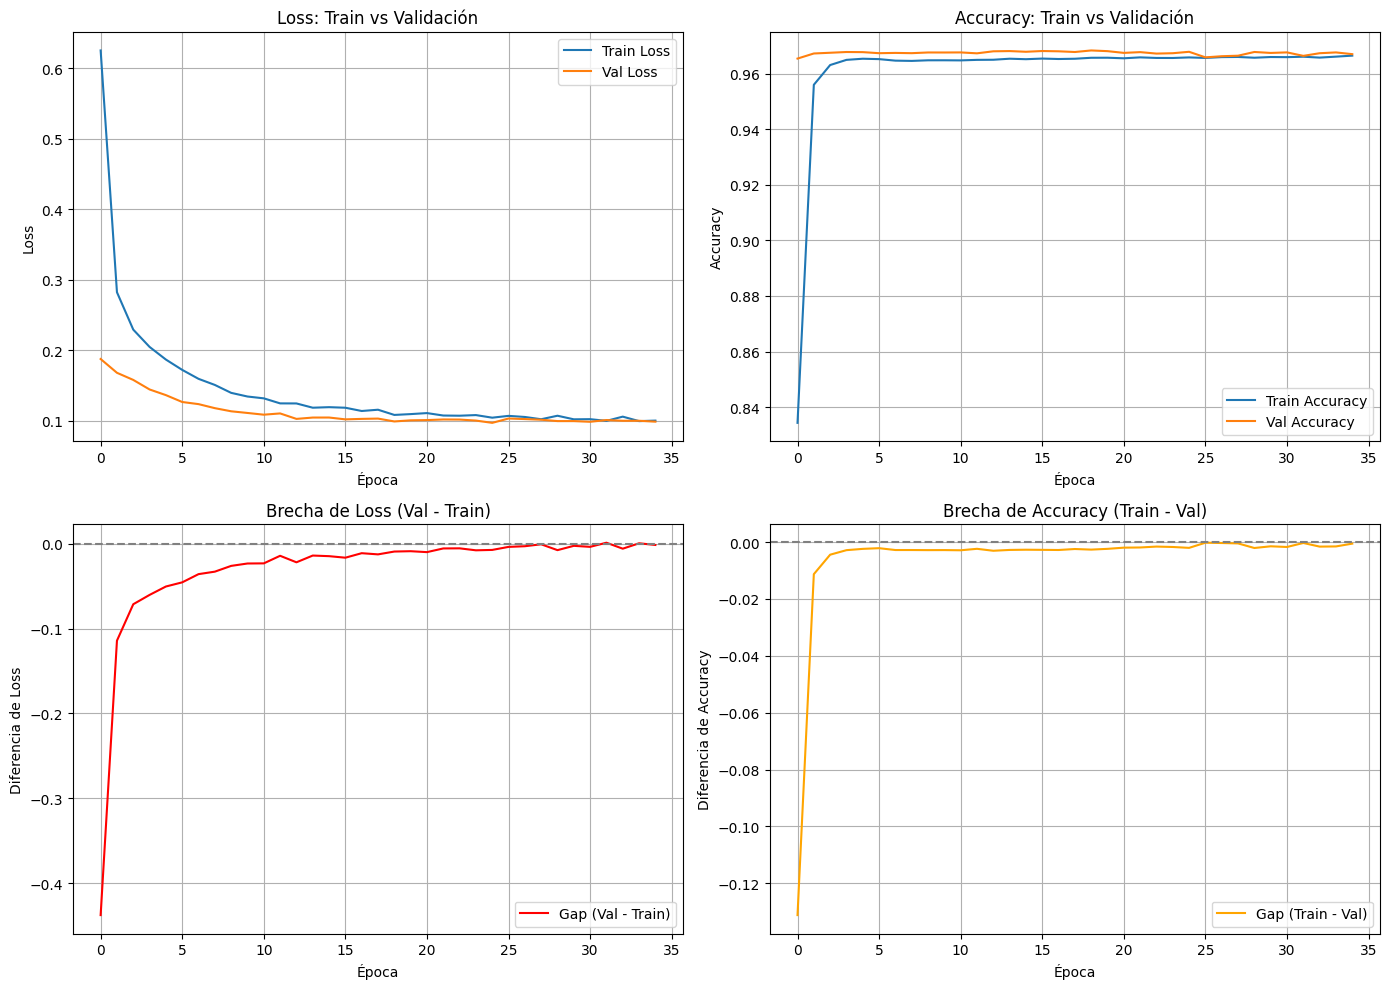

DIAGNÓSTICO DE SOBREENTRENAMIENTO

Loss final (Train): 0.1001
Loss final (Val):   0.0986
Mejor Val Loss:     0.0969 (época 25)
Brecha Loss final:  -0.0015
Ratio Val/Train Loss: 0.9851
✓ Ratio aceptable, no se detecta sobreentrenamiento severo.

COMPARACIÓN TRAIN vs TEST (Indicadores de Generalización)
Métrica                             Train       Test     Brecha
------------------------------------------------------------
Accuracy                           0.9684     0.9490     0.0194
Balanced Accuracy                  0.9667     0.9325     0.0343
Log Loss (Cross-Entropy)           0.0950     0.1508     0.0558
Cohen Kappa                        0.9494     0.9363     0.0131
F1-Score Macro                     0.9464     0.9356     0.0108
F1-Score Weighted                  0.9684     0.9489     0.0195
MAE Ordinal                        0.0396     0.0657     0.0261
------------------------------------------------------------

INTERPRETACIÓN:
✓ Brecha de Accuracy < 5%: Buena generalizació

In [285]:
# ============================================================================
# DIAGNÓSTICO DE SOBREENTRENAMIENTO (OVERFITTING)
# ============================================================================
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    log_loss, cohen_kappa_score, f1_score, balanced_accuracy_score,
    mean_absolute_error
)
import matplotlib.pyplot as plt

# --- 1. Curvas de Entrenamiento vs Validación (detección visual de overfitting) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Loss: Train vs Validación')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0, 1].set_title('Accuracy: Train vs Validación')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Brecha (Gap) de Loss - indicador directo de overfitting
train_loss = np.array(history.history['loss'])
val_loss = np.array(history.history['val_loss'])
gap_loss = val_loss - train_loss
axes[1, 0].plot(gap_loss, label='Gap (Val - Train)', color='red')
axes[1, 0].axhline(y=0, color='gray', linestyle='--')
axes[1, 0].set_title('Brecha de Loss (Val - Train)')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Diferencia de Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Brecha de Accuracy
train_acc = np.array(history.history['accuracy'])
val_acc = np.array(history.history['val_accuracy'])
gap_acc = train_acc - val_acc
axes[1, 1].plot(gap_acc, label='Gap (Train - Val)', color='orange')
axes[1, 1].axhline(y=0, color='gray', linestyle='--')
axes[1, 1].set_title('Brecha de Accuracy (Train - Val)')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Diferencia de Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('diagnostico_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2. Métricas numéricas de sobreajuste ---
print("=" * 80)
print("DIAGNÓSTICO DE SOBREENTRENAMIENTO")
print("=" * 80)

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
best_val_loss = min(history.history['val_loss'])
best_epoch = np.argmin(history.history['val_loss']) + 1

print(f"\nLoss final (Train): {final_train_loss:.4f}")
print(f"Loss final (Val):   {final_val_loss:.4f}")
print(f"Mejor Val Loss:     {best_val_loss:.4f} (época {best_epoch})")
print(f"Brecha Loss final:  {final_val_loss - final_train_loss:.4f}")

# Ratio de overfitting: si val_loss/train_loss >> 1, hay sobreajuste
ratio = final_val_loss / (final_train_loss + 1e-8)
print(f"Ratio Val/Train Loss: {ratio:.4f}")

if ratio > 1.3:
    print("⚠️ ALERTA: Ratio > 1.3 indica posible sobreentrenamiento significativo.")
elif ratio > 1.1:
    print("⚠️ PRECAUCIÓN: Ratio > 1.1, leve sobreentrenamiento detectado.")
else:
    print("✓ Ratio aceptable, no se detecta sobreentrenamiento severo.")

# --- 3. Evaluación sobre Train y Test para comparar ---
y_pred_train = model.predict(X_train_final, verbose=0)
y_pred_test = model.predict(X_test_final, verbose=0)

y_pred_train_labels = np.argmax(y_pred_train, axis=1)
y_pred_test_labels = np.argmax(y_pred_test, axis=1)
y_true_train_labels = np.argmax(y_train_final.values, axis=1)
y_true_test_labels = np.argmax(y_test.values, axis=1)

# Accuracy
acc_train = accuracy_score(y_true_train_labels, y_pred_train_labels)
acc_test = accuracy_score(y_true_test_labels, y_pred_test_labels)

# Balanced Accuracy (importante con clases desbalanceadas)
bal_acc_train = balanced_accuracy_score(y_true_train_labels, y_pred_train_labels)
bal_acc_test = balanced_accuracy_score(y_true_test_labels, y_pred_test_labels)

# Log Loss (Cross-Entropy sobre probabilidades)
logloss_train = log_loss(y_train_final.values, y_pred_train)
logloss_test = log_loss(y_test.values, y_pred_test)

# Cohen's Kappa (acuerdo ajustado por azar)
kappa_train = cohen_kappa_score(y_true_train_labels, y_pred_train_labels)
kappa_test = cohen_kappa_score(y_true_test_labels, y_pred_test_labels)

# F1-Score Macro (equilibra métricas entre clases)
f1_macro_train = f1_score(y_true_train_labels, y_pred_train_labels, average='macro', zero_division=0)
f1_macro_test = f1_score(y_true_test_labels, y_pred_test_labels, average='macro', zero_division=0)

# F1-Score Weighted
f1_weighted_train = f1_score(y_true_train_labels, y_pred_train_labels, average='weighted', zero_division=0)
f1_weighted_test = f1_score(y_true_test_labels, y_pred_test_labels, average='weighted', zero_division=0)

# MAE ordinal (mide qué tan lejos están las predicciones de la clase verdadera)
mae_train = mean_absolute_error(y_true_train_labels, y_pred_train_labels)
mae_test = mean_absolute_error(y_true_test_labels, y_pred_test_labels)

print("\n" + "=" * 80)
print("COMPARACIÓN TRAIN vs TEST (Indicadores de Generalización)")
print("=" * 80)
print(f"{'Métrica':<30} {'Train':>10} {'Test':>10} {'Brecha':>10}")
print("-" * 60)
print(f"{'Accuracy':<30} {acc_train:>10.4f} {acc_test:>10.4f} {acc_train - acc_test:>10.4f}")
print(f"{'Balanced Accuracy':<30} {bal_acc_train:>10.4f} {bal_acc_test:>10.4f} {bal_acc_train - bal_acc_test:>10.4f}")
print(f"{'Log Loss (Cross-Entropy)':<30} {logloss_train:>10.4f} {logloss_test:>10.4f} {logloss_test - logloss_train:>10.4f}")
print(f"{'Cohen Kappa':<30} {kappa_train:>10.4f} {kappa_test:>10.4f} {kappa_train - kappa_test:>10.4f}")
print(f"{'F1-Score Macro':<30} {f1_macro_train:>10.4f} {f1_macro_test:>10.4f} {f1_macro_train - f1_macro_test:>10.4f}")
print(f"{'F1-Score Weighted':<30} {f1_weighted_train:>10.4f} {f1_weighted_test:>10.4f} {f1_weighted_train - f1_weighted_test:>10.4f}")
print(f"{'MAE Ordinal':<30} {mae_train:>10.4f} {mae_test:>10.4f} {mae_test - mae_train:>10.4f}")
print("-" * 60)

# Interpretación automática
print("\nINTERPRETACIÓN:")
if (acc_train - acc_test) > 0.10:
    print("⚠️ Brecha de Accuracy > 10%: SOBREENTRENAMIENTO probable.")
elif (acc_train - acc_test) > 0.05:
    print("⚠️ Brecha de Accuracy entre 5-10%: Leve sobreentrenamiento.")
else:
    print("✓ Brecha de Accuracy < 5%: Buena generalización.")

if (logloss_test - logloss_train) > 0.5:
    print("⚠️ Brecha de Log Loss > 0.5: El modelo está muy seguro en train pero no en test.")
else:
    print("✓ Log Loss aceptable entre conjuntos.")

In [286]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

# --- 1. CONFIGURACIÓN Y CARGA ---
MODEL_PATH = "best_mlp_sequia.h5"

try:
    # Cargar el modelo guardado con los mejores pesos
    model = load_model(MODEL_PATH)
    print(f"✅ Modelo cargado correctamente desde: {MODEL_PATH}")
except Exception as e:
    print(f"❌ Error al cargar el modelo. Asegúrate de que el archivo existe: {e}")
    # Si hay un error, puedes usar el objeto 'model' entrenado en la sesión
    # si la ejecución de entrenamiento fue reciente.
    pass

# --- 2. PREDICCIÓN ---
print("\n--- REALIZANDO PREDICCIONES EN EL CONJUNTO DE PRUEBA (X_test_final) ---")

# Generar probabilidades (OHE) para el conjunto de prueba
y_pred_probs = model.predict(X_test_final, verbose=0)

# Convertir probabilidades (OHE) a etiquetas de clase (0 a 5)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Convertir el target de prueba real (y_test) a etiquetas de clase
y_true_labels = np.argmax(y_test.values, axis=1)

print(f"Predicciones generadas para {len(y_test)} registros.")

✅ Modelo cargado correctamente desde: best_mlp_sequia.h5

--- REALIZANDO PREDICCIONES EN EL CONJUNTO DE PRUEBA (X_test_final) ---
Predicciones generadas para 679824 registros.


In [287]:
# --- 3. REPORTE DE CLASIFICACIÓN DETALLADO (MÉTRICAS CLAVE) ---
print("\n--- 3. REPORTE DE CLASIFICACIÓN DETALLADO ---")

# Mapeo de nombres para la tabla final
target_names = ['Sin Sequía (0)', 'D0 (1)', 'D1 (2)', 'D2 (3)', 'D3 (4)', 'D4 (5)']

reporte = classification_report(
    y_true_labels,
    y_pred_labels,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, zero_division=0))

# Extraer y mostrar las métricas más importantes
accuracy_general = accuracy_score(y_true_labels, y_pred_labels)
print(f"\nAccuracy General (Global): {accuracy_general:.4f}")
print(f"Macro Average Precision: {reporte['macro avg']['precision']:.4f}")
print(f"Macro Average Recall: {reporte['macro avg']['recall']:.4f}")
print("-" * 40)
print(f"Recall (Capacidad de Detección) de Sequía Extrema (D3): {reporte['D3 (4)']['recall']:.4f}")
print(f"Recall (Capacidad de Detección) de Sequía Excepcional (D4): {reporte['D4 (5)']['recall']:.4f}")


--- 3. REPORTE DE CLASIFICACIÓN DETALLADO ---
                precision    recall  f1-score   support

Sin Sequía (0)       0.97      0.95      0.96    158513
        D0 (1)       0.94      0.95      0.94    159630
        D1 (2)       0.96      0.94      0.95    140072
        D2 (3)       0.94      0.97      0.95    118017
        D3 (4)       0.94      0.97      0.95     86616
        D4 (5)       0.89      0.83      0.86     16976

      accuracy                           0.95    679824
     macro avg       0.94      0.93      0.94    679824
  weighted avg       0.95      0.95      0.95    679824


Accuracy General (Global): 0.9490
Macro Average Precision: 0.9393
Macro Average Recall: 0.9325
----------------------------------------
Recall (Capacidad de Detección) de Sequía Extrema (D3): 0.9671
Recall (Capacidad de Detección) de Sequía Excepcional (D4): 0.8253


In [288]:
print("\n--- 4. MATRIZ DE CONFUSIÓN (TRUE vs. PREDICTED) ---")
conf_mat = confusion_matrix(y_true_labels, y_pred_labels)
print(conf_mat)


--- 4. MATRIZ DE CONFUSIÓN (TRUE vs. PREDICTED) ---
[[150981   5276   1265    662    168    161]
 [  3967 151108   2609   1373    387    186]
 [   493   3872 131144   3785    561    217]
 [   125    673   1629 114127   1148    315]
 [    29    130    165   1639  83769    884]
 [    11     29     29    100   2796  14011]]


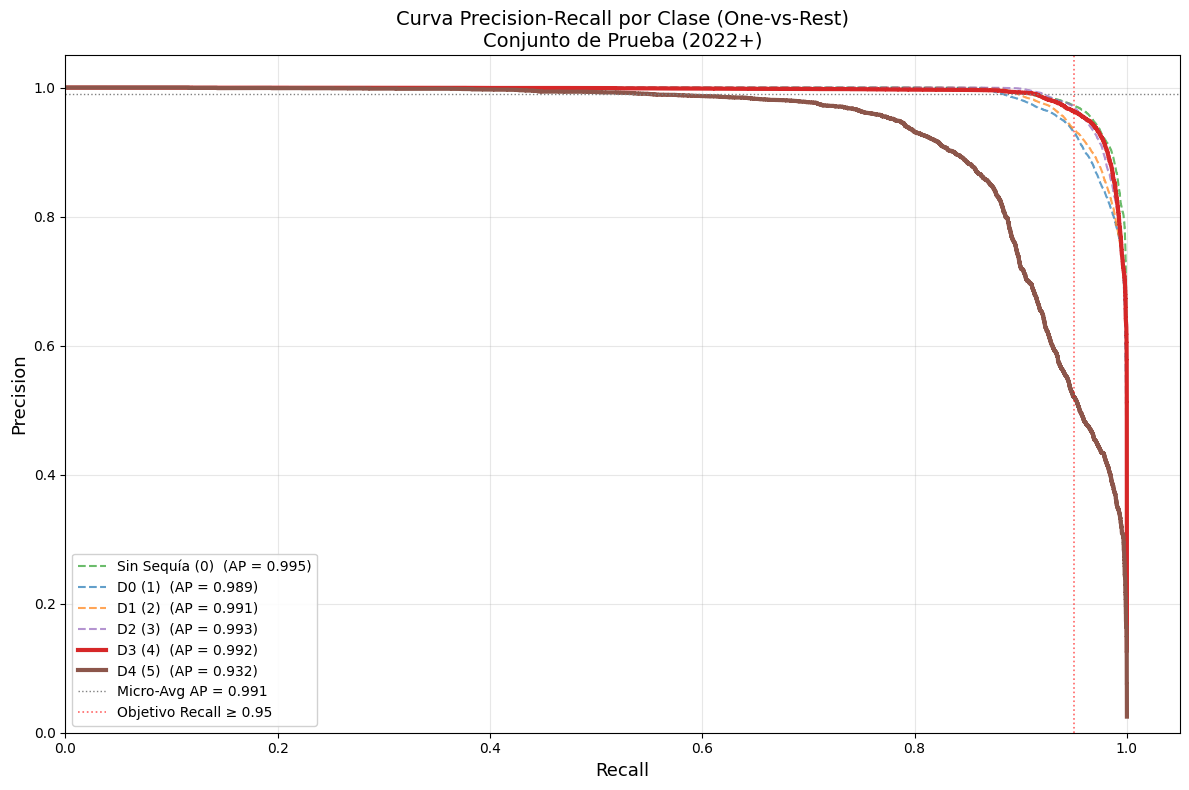

AVERAGE PRECISION (AP) POR CLASE
Clase                      AP     Objetivo
------------------------------------------
Sin Sequía (0)         0.9945              
D0 (1)                 0.9894              
D1 (2)                 0.9907              
D2 (3)                 0.9933              
D3 (4)                 0.9924    ≥ 0.95 ⚠️ ✓
D4 (5)                 0.9316    ≥ 0.95 ⚠️ ✗
------------------------------------------
Micro-Average          0.9905

RECALL POR CLASE EN PUNTO DE OPERACIÓN (argmax)
  Sin Sequía (0)       Recall = 0.9525  
  D0 (1)               Recall = 0.9466  
  D1 (2)               Recall = 0.9363  
  D2 (3)               Recall = 0.9670  
  D3 (4)               Recall = 0.9671  ✓ CUMPLE
  D4 (5)               Recall = 0.8253  ✗ NO CUMPLE


In [289]:
# ============================================================================
# CURVA PRECISION-RECALL (PR) Y AVERAGE PRECISION (AP) - One-vs-Rest
# ============================================================================
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Preparar datos en formato One-vs-Rest ---
target_names = ['Sin Sequía (0)', 'D0 (1)', 'D1 (2)', 'D2 (3)', 'D3 (4)', 'D4 (5)']
n_classes = len(target_names)

# Binarizar labels reales (OvR): y_test ya está en OHE, usarlo directamente
y_true_bin = y_test.values  # shape: (n_samples, 6)

# Probabilidades predichas por el modelo
y_pred_probs = model.predict(X_test_final, verbose=0)  # shape: (n_samples, 6)

# --- 2. Calcular PR curve y AP para cada clase ---
precision_dict = {}
recall_dict = {}
ap_dict = {}

for i in range(n_classes):
    precision_dict[i], recall_dict[i], _ = precision_recall_curve(
        y_true_bin[:, i], y_pred_probs[:, i]
    )
    ap_dict[i] = average_precision_score(y_true_bin[:, i], y_pred_probs[:, i])

# AP micro-average (todas las clases combinadas)
ap_micro = average_precision_score(y_true_bin, y_pred_probs, average='micro')

# --- 3. Graficar ---
fig, ax = plt.subplots(figsize=(12, 8))

# Colores por clase
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#9467bd', '#d62728', '#8c564b']

# Clases críticas (D3=4, D4=5) se dibujan con línea gruesa
clases_criticas = {4, 5}

for i in range(n_classes):
    lw = 3.0 if i in clases_criticas else 1.5
    ls = '-' if i in clases_criticas else '--'
    alpha = 1.0 if i in clases_criticas else 0.7

    ax.plot(
        recall_dict[i], precision_dict[i],
        color=colors[i], linewidth=lw, linestyle=ls, alpha=alpha,
        label=f'{target_names[i]}  (AP = {ap_dict[i]:.3f})'
    )

# Línea de referencia: AP micro-average
ax.axhline(y=ap_micro, color='gray', linestyle=':', linewidth=1,
           label=f'Micro-Avg AP = {ap_micro:.3f}')

# Línea vertical en Recall = 0.95 (objetivo de la tesis)
ax.axvline(x=0.95, color='red', linestyle=':', linewidth=1.2, alpha=0.6,
           label='Objetivo Recall ≥ 0.95')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Curva Precision-Recall por Clase (One-vs-Rest)\nConjunto de Prueba (2022+)', fontsize=14)
ax.set_xlim([0.0, 1.05])
ax.set_ylim([0.0, 1.05])
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 4. Tabla resumen de AP por clase ---
print("=" * 60)
print("AVERAGE PRECISION (AP) POR CLASE")
print("=" * 60)
print(f"{'Clase':<20} {'AP':>8} {'Objetivo':>12}")
print("-" * 42)
for i in range(n_classes):
    objetivo = '≥ 0.95 ⚠️' if i in clases_criticas else ''
    cumple = '✓' if i in clases_criticas and ap_dict[i] >= 0.95 else ('✗' if i in clases_criticas else '')
    print(f"{target_names[i]:<20} {ap_dict[i]:>8.4f} {objetivo:>12} {cumple}")
print("-" * 42)
print(f"{'Micro-Average':<20} {ap_micro:>8.4f}")

# --- 5. Verificar Recall en el punto de operación (umbral por defecto = argmax) ---
print("\n" + "=" * 60)
print("RECALL POR CLASE EN PUNTO DE OPERACIÓN (argmax)")
print("=" * 60)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_true_bin, axis=1)

from sklearn.metrics import recall_score
recalls = recall_score(y_true_labels, y_pred_labels, average=None, zero_division=0)
for i in range(n_classes):
    estado = ''
    if i in clases_criticas:
        estado = '✓ CUMPLE' if recalls[i] >= 0.95 else '✗ NO CUMPLE'
    print(f"  {target_names[i]:<20} Recall = {recalls[i]:.4f}  {estado}")

## 12.7) Métricas avanzadas de confiabilidad y decisión operativa

### ¿Qué se hace en esta sección?
1. Se calcula **Cohen's Kappa cuadrático** para evaluar concordancia ordinal entre clases de sequía.
2. Se calcula **Expected Calibration Error (ECE)** para medir si la confianza del modelo coincide con su precisión real.
3. Se construye la **curva Confianza vs. Cobertura (Selective Prediction)** para simular una política operativa de rechazo de predicciones poco confiables.
4. Se generan **tablas y gráficas** listas para documentación en tesis o integración web.

### Técnica usada
- `cohen_kappa_score(..., weights='quadratic')` de `sklearn.metrics`.
- Diagrama de calibración con `calibration_curve` de `sklearn.calibration`.
- Cálculo ECE multicategoría por binning de confianza máxima (`max softmax`).
- Evaluación Selective Prediction por cobertura top-X%.

### ¿Por qué es importante para este problema?
- La sequía es un fenómeno **ordinal** (D0 < D1 < D2 < D3 < D4): errores lejanos deben penalizarse más.
- Si el sistema web muestra probabilidades, la **calibración** determina si esas probabilidades son confiables para decidir acciones.
- La política de **semaforización por confianza** permite una operación más segura (actuar, verificar o escalar a experto).


12.7.1) COHEN KAPPA CUADRÁTICO
Interpretación rápida de Kappa:
<0.00: pobre | 0.00-0.20: leve | 0.21-0.40: aceptable | 0.41-0.60: moderada
0.61-0.80: sustancial | 0.81-1.00: casi perfecta


,metrica,valor
0,Accuracy global,0.948981
1,Cohen Kappa cuadratico,0.973866



12.7.2) EXPECTED CALIBRATION ERROR (ECE)
ECE (multiclase, max-softmax, 15 bins): 0.004537
Regla práctica: mientras más cercano a 0, mejor calibración.


,bin,conf_min,conf_max,n,accuracy_bin,confidence_bin,gap_abs,weighted_gap
0,1,0.000000,0.066667,0,NaN,NaN,NaN,0.000000e+00
1,2,0.066667,0.133333,0,NaN,NaN,NaN,0.000000e+00
2,3,0.133333,0.200000,3,0.333333,0.195992,0.137342,6.060765e-07
3,4,0.200000,0.266667,540,0.220370,0.244757,0.024387,1.937082e-05
4,5,0.266667,0.333333,2621,0.293399,0.304241,0.010842,4.179902e-05
5,6,0.333333,0.400000,5090,0.361886,0.370189,0.008303,6.216976e-05
6,7,0.400000,0.466667,9568,0.455268,0.436483,0.018784,2.643766e-04
7,8,0.466667,0.533333,11491,0.558872,0.500705,0.058167,9.831909e-04
8,9,0.533333,0.600000,13189,0.650390,0.567225,0.083165,1.613452e-03
9,10,0.600000,0.666667,14325,0.642513,0.632641,0.009872,2.080144e-04


✓ Tabla ECE por bins guardada en 'tabla_ece_bins.csv'


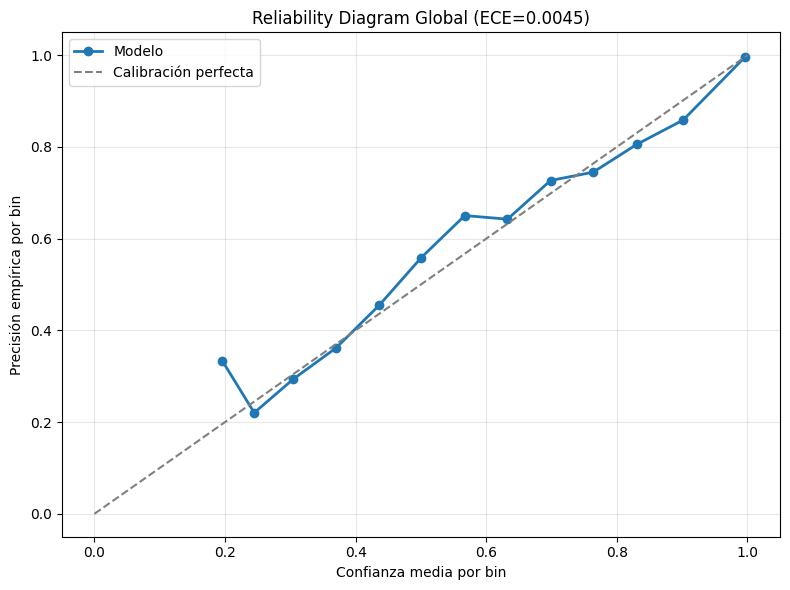

✓ Gráfico guardado: 'reliability_diagram_global.png'


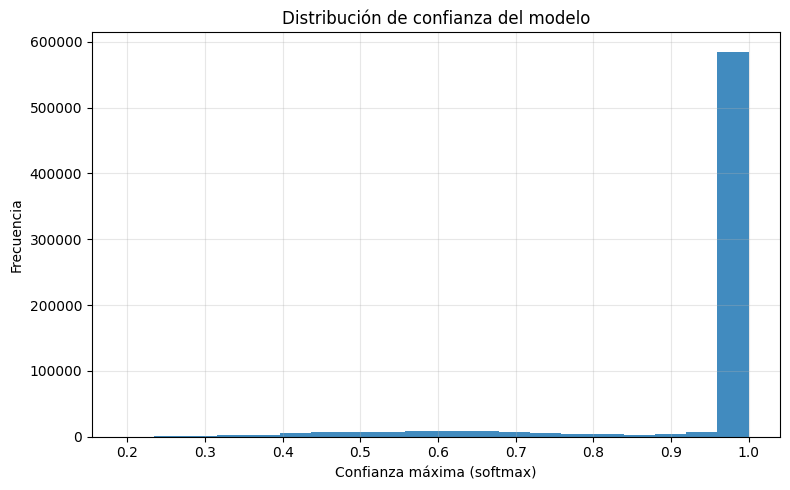

✓ Gráfico guardado: 'histograma_confianza_modelo.png'

12.7.5) CURVA CONFIANZA VS COBERTURA (SELECTIVE PREDICTION)


,coverage,n_samples,confidence_threshold_min,accuracy_selectivo
0,0.1,67982,0.999918,0.999985
1,0.2,135964,0.999798,0.999978
2,0.3,203947,0.999632,0.999975
3,0.4,271929,0.999383,0.999960
4,0.5,339912,0.999024,0.999932
5,0.6,407894,0.998125,0.999831
6,0.7,475876,0.996438,0.999645
7,0.8,543859,0.991203,0.999235
8,0.9,611841,0.728900,0.990087
9,1.0,679824,0.194697,0.948981


✓ Tabla guardada en 'tabla_confianza_vs_cobertura.csv'


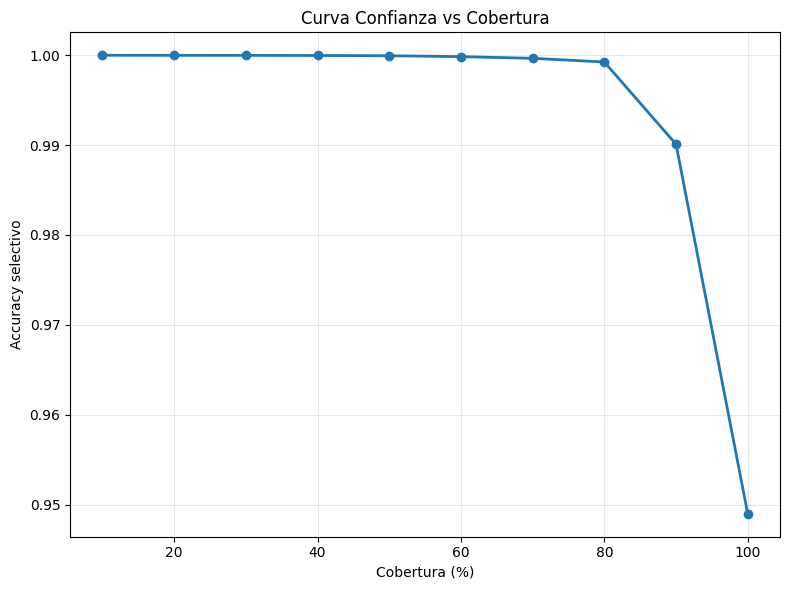

✓ Gráfico guardado: 'curva_confianza_vs_cobertura.png'

SEMAFORIZACIÓN OPERATIVA POR CONFIANZA


,banda,muestras,accuracy_banda
0,Verde (>0.80),602661,0.993783
1,Amarillo (0.50-0.80),53836,0.674289
2,Rojo (<0.50),23327,0.425473


✓ Tabla guardada en 'tabla_semaforo_confianza.csv'

Resumen ejecutivo:
- Accuracy global: 0.9490
- Kappa cuadrático: 0.9739
- ECE global: 0.004537
- Política recomendada: actuar en verde, verificar en amarillo, escalar experto en rojo.


In [290]:
# ============================================================================
# 12.7) KAPPA CUADRÁTICO, ECE Y SELECTIVE PREDICTION
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, accuracy_score
from sklearn.calibration import calibration_curve

# ---------------------------------------------------------------------------
# 0) Verificación de variables necesarias
# ---------------------------------------------------------------------------
# Reutiliza variables ya calculadas en el notebook. Si faltan, intenta crearlas.
if 'y_pred_probs' not in globals() or y_pred_probs is None:
    if 'model' in globals() and 'X_test_final' in globals():
        y_pred_probs = model.predict(X_test_final, verbose=0)
    else:
        raise ValueError("No existe y_pred_probs ni variables para recalcularlo (model, X_test_final).")

if 'y_true_labels' not in globals() or y_true_labels is None:
    if 'y_test' in globals():
        y_true_labels = np.argmax(y_test.values, axis=1)
    else:
        raise ValueError("No existe y_true_labels ni y_test para reconstruir etiquetas reales.")

if 'y_pred_labels' not in globals() or y_pred_labels is None:
    y_pred_labels = np.argmax(y_pred_probs, axis=1)

if 'target_names' not in globals() or target_names is None:
    target_names = [f"Clase {i}" for i in range(y_pred_probs.shape[1])]

n_classes = y_pred_probs.shape[1]

# ---------------------------------------------------------------------------
# 1) 12.7.1 - Cohen's Kappa cuadrático (ordinal)
# ---------------------------------------------------------------------------
qwk = cohen_kappa_score(y_true_labels, y_pred_labels, weights='quadratic')
acc_global = accuracy_score(y_true_labels, y_pred_labels)

df_kappa = pd.DataFrame({
    'metrica': ['Accuracy global', 'Cohen Kappa cuadratico'],
    'valor': [acc_global, qwk]
})

print("\n" + "=" * 72)
print("12.7.1) COHEN KAPPA CUADRÁTICO")
print("=" * 72)
print("Interpretación rápida de Kappa:")
print("<0.00: pobre | 0.00-0.20: leve | 0.21-0.40: aceptable | 0.41-0.60: moderada")
print("0.61-0.80: sustancial | 0.81-1.00: casi perfecta")
display(df_kappa)

# ---------------------------------------------------------------------------
# 2) 12.7.2 - Expected Calibration Error (ECE)
# ---------------------------------------------------------------------------
# ECE multicategoría usando la confianza máxima (max softmax).
confianza_max = np.max(y_pred_probs, axis=1)
correctas = (y_pred_labels == y_true_labels).astype(int)

n_bins = 15
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
bin_ids = np.digitize(confianza_max, bin_edges[1:-1], right=True)

rows = []
ece = 0.0
for b in range(n_bins):
    mask = bin_ids == b
    n_b = int(mask.sum())
    if n_b == 0:
        rows.append({
            'bin': b + 1,
            'conf_min': float(bin_edges[b]),
            'conf_max': float(bin_edges[b + 1]),
            'n': 0,
            'accuracy_bin': np.nan,
            'confidence_bin': np.nan,
            'gap_abs': np.nan,
            'weighted_gap': 0.0
        })
        continue

    acc_b = float(correctas[mask].mean())
    conf_b = float(confianza_max[mask].mean())
    gap = abs(acc_b - conf_b)
    w_gap = (n_b / len(confianza_max)) * gap
    ece += w_gap

    rows.append({
        'bin': b + 1,
        'conf_min': float(bin_edges[b]),
        'conf_max': float(bin_edges[b + 1]),
        'n': n_b,
        'accuracy_bin': acc_b,
        'confidence_bin': conf_b,
        'gap_abs': gap,
        'weighted_gap': w_gap
    })

df_ece_bins = pd.DataFrame(rows)

print("\n" + "=" * 72)
print("12.7.2) EXPECTED CALIBRATION ERROR (ECE)")
print("=" * 72)
print(f"ECE (multiclase, max-softmax, {n_bins} bins): {ece:.6f}")
print("Regla práctica: mientras más cercano a 0, mejor calibración.")

display(df_ece_bins)

# Guardar tabla de bins para reporte/tesis
df_ece_bins.to_csv('tabla_ece_bins.csv', index=False)
print("✓ Tabla ECE por bins guardada en 'tabla_ece_bins.csv'")

# --- Gráfica 1: Reliability diagram (global) ---
# Para consistencia visual, usamos calibration_curve en esquema binario:
# evento = predicción correcta (1) vs incorrecta (0)
frac_pos, mean_pred = calibration_curve(correctas, confianza_max, n_bins=n_bins, strategy='uniform')

plt.figure(figsize=(8, 6))
plt.plot(mean_pred, frac_pos, marker='o', linewidth=2, label='Modelo')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibración perfecta')
plt.xlabel('Confianza media por bin')
plt.ylabel('Precisión empírica por bin')
plt.title(f'Reliability Diagram Global (ECE={ece:.4f})')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('reliability_diagram_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado: 'reliability_diagram_global.png'")

# --- Gráfica 2: Histograma de confianza ---
plt.figure(figsize=(8, 5))
plt.hist(confianza_max, bins=20, alpha=0.85)
plt.xlabel('Confianza máxima (softmax)')
plt.ylabel('Frecuencia')
plt.title('Distribución de confianza del modelo')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('histograma_confianza_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado: 'histograma_confianza_modelo.png'")

# ---------------------------------------------------------------------------
# 3) 12.7.5 - Curva confianza vs cobertura (Selective Prediction)
# ---------------------------------------------------------------------------
# Ordena predicciones por confianza descendente y calcula accuracy acumulada.
order = np.argsort(-confianza_max)
conf_sorted = confianza_max[order]
corr_sorted = correctas[order]

coverage_grid = np.linspace(0.10, 1.00, 10)  # 10% ... 100%
rows_cov = []

for cov in coverage_grid:
    k = max(1, int(len(conf_sorted) * cov))
    acc_cov = float(corr_sorted[:k].mean())
    umbral_cov = float(conf_sorted[k - 1])
    rows_cov.append({
        'coverage': cov,
        'n_samples': k,
        'confidence_threshold_min': umbral_cov,
        'accuracy_selectivo': acc_cov
    })

df_cobertura = pd.DataFrame(rows_cov)

print("\n" + "=" * 72)
print("12.7.5) CURVA CONFIANZA VS COBERTURA (SELECTIVE PREDICTION)")
print("=" * 72)
display(df_cobertura)

# Guardar tabla de cobertura para reporte/tesis
df_cobertura.to_csv('tabla_confianza_vs_cobertura.csv', index=False)
print("✓ Tabla guardada en 'tabla_confianza_vs_cobertura.csv'")

# Gráfica de accuracy selectivo vs cobertura
plt.figure(figsize=(8, 6))
plt.plot(df_cobertura['coverage'] * 100, df_cobertura['accuracy_selectivo'], marker='o', linewidth=2)
plt.xlabel('Cobertura (%)')
plt.ylabel('Accuracy selectivo')
plt.title('Curva Confianza vs Cobertura')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('curva_confianza_vs_cobertura.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado: 'curva_confianza_vs_cobertura.png'")

# ---------------------------------------------------------------------------
# 4) Semaforización operativa por bandas de confianza
# ---------------------------------------------------------------------------
# Bandas sugeridas para despliegue web: alta (>0.8), media (0.5-0.8), baja (<0.5)
def banda_confianza(c):
    if c > 0.80:
        return 'Verde (>0.80)'
    if c >= 0.50:
        return 'Amarillo (0.50-0.80)'
    return 'Rojo (<0.50)'

bandas = pd.Series(confianza_max).apply(banda_confianza)
df_semaforo = pd.DataFrame({
    'banda': bandas,
    'correcta': correctas
}).groupby('banda', as_index=False).agg(
    muestras=('correcta', 'count'),
    accuracy_banda=('correcta', 'mean')
)

# Orden lógico de presentación
orden_bandas = ['Verde (>0.80)', 'Amarillo (0.50-0.80)', 'Rojo (<0.50)']
df_semaforo['banda'] = pd.Categorical(df_semaforo['banda'], categories=orden_bandas, ordered=True)
df_semaforo = df_semaforo.sort_values('banda').reset_index(drop=True)

print("\n" + "=" * 72)
print("SEMAFORIZACIÓN OPERATIVA POR CONFIANZA")
print("=" * 72)
display(df_semaforo)

df_semaforo.to_csv('tabla_semaforo_confianza.csv', index=False)
print("✓ Tabla guardada en 'tabla_semaforo_confianza.csv'")

# Resumen ejecutivo para tesis
print("\nResumen ejecutivo:")
print(f"- Accuracy global: {acc_global:.4f}")
print(f"- Kappa cuadrático: {qwk:.4f}")
print(f"- ECE global: {ece:.6f}")
print("- Política recomendada: actuar en verde, verificar en amarillo, escalar experto en rojo.")

## 13) Visualizaciones de apoyo y validación final
### ¿Qué se hace en esta sección?
1. Se crean funciones reutilizables para curvas de entrenamiento y heatmap de confusión.
2. Se recarga el mejor modelo guardado y se evalúa nuevamente en test.
3. Se generan gráficos exportables para reporte técnico/tesis.

### Técnica usada
- **Funcionalización de visualizaciones para reproducibilidad analítica**.

### ¿Por qué es importante para este problema?
- Estandariza la interpretación de resultados.
- Permite comunicar desempeño del modelo de forma consistente.

In [194]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [291]:
def plot_training_history(history):
    """Genera las curvas de Pérdida y Accuracy (Train vs. Validation)."""
    plt.figure(figsize=(12, 5))

    # Curva de Pérdida (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Pérdida (Train)')
    plt.plot(history.history['val_loss'], label='Pérdida (Validación)')
    plt.title('Curvas de Pérdida (Loss)')
    plt.ylabel('Pérdida')
    plt.xlabel('Época')
    plt.legend()

    # Curva de Precisión (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Accuracy (Train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (Validación)')
    plt.title('Curvas de Precisión (Accuracy)')
    plt.ylabel('Accuracy')
    plt.xlabel('Época')
    plt.legend()
    plt.savefig('training_history_curves.png')
    plt.close()
    print("✓ Gráfico de curvas de entrenamiento guardado como 'training_history_curves.png'")

In [292]:

def plot_confusion_matrix(y_true, y_pred, target_names, filename='confusion_matrix_heatmap.png'):
    """Genera la matriz de confusión como un mapa de calor."""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names
    )
    plt.title('Matriz de Confusión (Cuentas Absolutas)')
    plt.ylabel('Etiqueta Verdadera (True)')
    plt.xlabel('Etiqueta Predicha (Predicted)')
    plt.savefig(filename)
    plt.close()
    print(f"✓ Matriz de Confusión (Heatmap) guardada como '{filename}'")

In [293]:
# --- UTILIDADES DE VISUALIZACIÓN ---

# Asume que 'X_test_final', 'y_test' están disponibles.
MODEL_PATH = "best_mlp_sequia.h5"
target_names = ['Sin Sequía (0)', 'D0 (1)', 'D1 (2)', 'D2 (3)', 'D3 (4)', 'D4 (5)']

try:
    # Cargar el modelo con los mejores pesos
    model = load_model(MODEL_PATH)
    print(f"\n--- EVALUACIÓN FINAL DEL MODELO CARGADO ---")

    # a) Predicción y Conversión a Etiquetas
    y_pred_probs = model.predict(X_test_final, verbose=0)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)
    y_true_labels = np.argmax(y_test.values, axis=1)

    # b) Métricas Generales (Salida de la sección 2 del documento)
    loss, accuracy, precision, recall = model.evaluate(X_test_final, y_test, verbose=0)
    print(f"Pérdida (Test): {loss:.4f} | Accuracy General: {accuracy:.4f}")

    # c) Reporte Detallado de Clasificación
    print("\n--- REPORTE DE CLASIFICACIÓN (MÉTRICAS POR CLASE) ---")
    reporte = classification_report(y_true_labels, y_pred_labels, target_names=target_names, zero_division=0)
    print(reporte)

    # d) Generación de Gráficos (Salidas visuales para la sección 2)
    # Debes pasar el objeto 'history' resultante del model.fit()
    plot_training_history(history)

    plot_confusion_matrix(y_true_labels, y_pred_labels, target_names)

except Exception as e:
    print(f"\n❌ ERROR: La evaluación no pudo completarse. Asegúrate de que el objeto 'history' (del entrenamiento) y el archivo '{MODEL_PATH}' existen.")
    print(f"Detalle del error: {e}")


--- EVALUACIÓN FINAL DEL MODELO CARGADO ---
Pérdida (Test): 0.1508 | Accuracy General: 0.9490

--- REPORTE DE CLASIFICACIÓN (MÉTRICAS POR CLASE) ---
                precision    recall  f1-score   support

Sin Sequía (0)       0.97      0.95      0.96    158513
        D0 (1)       0.94      0.95      0.94    159630
        D1 (2)       0.96      0.94      0.95    140072
        D2 (3)       0.94      0.97      0.95    118017
        D3 (4)       0.94      0.97      0.95     86616
        D4 (5)       0.89      0.83      0.86     16976

      accuracy                           0.95    679824
     macro avg       0.94      0.93      0.94    679824
  weighted avg       0.95      0.95      0.95    679824

✓ Gráfico de curvas de entrenamiento guardado como 'training_history_curves.png'
✓ Matriz de Confusión (Heatmap) guardada como 'confusion_matrix_heatmap.png'


## 14) Empaquetado de artefactos para inferencia
### ¿Qué se hace en esta sección?
1. Se construye un paquete con scaler, columnas esperadas y metadatos del modelo.
2. Se guarda un `.pkl` con artefactos auxiliares y un `.keras` con el modelo.
3. Se verifica lectura del paquete para asegurar consistencia.

### Técnica usada
- **Serialización de pipeline de inferencia**.

### ¿Por qué es importante para este problema?
- Predicción en producción requiere exactamente el mismo preprocesamiento del entrenamiento.
- Evita errores de incompatibilidad entre entrenamiento y despliegue.

In [201]:
# ============================================================================
# GUARDAR MODELO Y ARTEFACTOS COMO .PKL (para despliegue web)
# ============================================================================
import pickle

# feature_cols_pred: las columnas REALES que el modelo recibe (sin 'lluvias' cruda)
feature_cols_pred = X_train_final.columns.tolist()

# Paquete completo: modelo Keras, scaler, feature_cols y mapeos
modelo_completo = {
    'model_weights_path': MODEL_CHECKPOINT_PATH,  # Referencia al archivo .h5
    'scaler': scaler,                              # StandardScaler ajustado
    'feature_cols': feature_cols_pred,             # Lista de features REALES del modelo (sin 'lluvias')
    'target_names': ['Sin sequía', 'D0', 'D1', 'D2', 'D3', 'D4'],
    'sequia_map': {'Sin sequía': 0, 'D0': 1, 'D1': 2, 'D2': 3, 'D3': 4, 'D4': 5},
    'class_weights': class_weights,
    'fecha_corte_entrenamiento': FECHA_CORTE,
    'lluvia_promedio_historico': lluvia_promedio_historico.to_dict(),
    'default_mean_lluvia': default_mean,
}

# Guardar artefactos auxiliares como .pkl
with open('modelo_entrenado.pkl', 'wb') as f:
    pickle.dump(modelo_completo, f)
print("✓ Artefactos del modelo guardados en 'modelo_entrenado.pkl'")

# Guardar también el modelo Keras en formato nativo (.keras) para compatibilidad actual
model.save('modelo_entrenado.keras')
print("✓ Modelo Keras guardado en 'modelo_entrenado.keras'")

# Verificar carga
with open('modelo_entrenado.pkl', 'rb') as f:
    verificacion = pickle.load(f)
print(f"\n✓ Verificación: {len(verificacion['feature_cols'])} features cargadas correctamente")
print(f"  Clases objetivo: {verificacion['target_names']}")
print(f"  Scaler tipo: {type(verificacion['scaler']).__name__}")
print(f"  ¿'lluvias' en feature_cols?: {'lluvias' in verificacion['feature_cols']}")

✓ Artefactos del modelo guardados en 'modelo_entrenado.pkl'
✓ Modelo Keras guardado en 'modelo_entrenado.keras'

✓ Verificación: 43 features cargadas correctamente
  Clases objetivo: ['Sin sequía', 'D0', 'D1', 'D2', 'D3', 'D4']
  Scaler tipo: StandardScaler
  ¿'lluvias' en feature_cols?: False


## 15) Especificación de entrada para aplicación web
### ¿Qué se hace en esta sección?
1. Se documentan campos obligatorios de formulario (tipos, ejemplo y rango).
2. Se listan variables históricas que el backend debe calcular (lags y rolling).
3. Se exporta la estructura de entrada a JSON para integración con frontend/backend.
4. Se incluye un ejemplo de función de predicción extremo a extremo.

### Técnica usada
- **Contrato de datos para inferencia (data contract)**.

### ¿Por qué es importante para este problema?
- Define de forma explícita qué datos necesita el modelo para operar.
- Reduce errores de integración al pasar de notebook a sistema web.

In [102]:
# ============================================================================
# ESTRUCTURA DE DATOS PARA PREDICCIÓN (FORMULARIO WEB)
# ============================================================================
import pickle
import json

# Cargar artefactos del modelo
with open('modelo_entrenado.pkl', 'rb') as f:
    artefactos = pickle.load(f)

print("=" * 80)
print("ESTRUCTURA DE DATOS REQUERIDA PARA GENERAR UNA PREDICCIÓN")
print("=" * 80)

# --- Features que el modelo espera (después del feature engineering) ---
print(f"\nEl modelo necesita {len(artefactos['feature_cols'])} features numéricas:")
for i, feat in enumerate(artefactos['feature_cols'], 1):
    print(f"  {i:2d}. {feat}")

# --- Campos del formulario web (datos originales que el usuario ingresa) ---
print("\n" + "=" * 80)
print("CAMPOS DEL FORMULARIO WEB (Datos de entrada del usuario)")
print("=" * 80)

campos_formulario = {
    "campos_obligatorios": {
        "lluvias": {
            "tipo": "float",
            "descripcion": "Precipitación en mm del mes consultado",
            "ejemplo": 85.3,
            "rango": "0 - 500+"
        },
        "temperaturamax": {
            "tipo": "float",
            "descripcion": "Temperatura máxima promedio del mes (°C)",
            "ejemplo": 32.5,
            "rango": "0 - 50"
        },
        "temperaturamin": {
            "tipo": "float",
            "descripcion": "Temperatura mínima promedio del mes (°C)",
            "ejemplo": 18.2,
            "rango": "-10 - 30"
        },
        "mes": {
            "tipo": "int",
            "descripcion": "Mes del año (1-12)",
            "ejemplo": 6,
            "rango": "1 - 12"
        },
        "año": {
            "tipo": "int",
            "descripcion": "Año de la consulta",
            "ejemplo": 2025,
            "rango": "2003 - actual"
        },
        "entidad": {
            "tipo": "string (select)",
            "descripcion": "Estado/Entidad federativa",
            "ejemplo": "Jalisco"
        },
        "nombre_mun": {
            "tipo": "string (select)",
            "descripcion": "Municipio",
            "ejemplo": "Guadalajara"
        },
        "pob_total": {
            "tipo": "int",
            "descripcion": "Población total del municipio",
            "ejemplo": 1385629,
            "rango": "1 - 2,000,000+"
        },
        "entidad_tiene_presa": {
            "tipo": "bool (checkbox)",
            "descripcion": "¿La entidad tiene presa?",
            "ejemplo": 1
        },
        "municipio_tiene_presa": {
            "tipo": "bool (checkbox)",
            "descripcion": "¿El municipio tiene presa?",
            "ejemplo": 0
        }
    },
    "campos_historicos_necesarios": {
        "nota": "Estos datos se calculan del historial; el backend debe tenerlos precargados o calcularlos",
        "sequia_num_lag_1": "Nivel de sequía del mes anterior (-1 a 4)",
        "sequia_num_lag_3": "Nivel de sequía hace 3 meses",
        "sequia_num_lag_6": "Nivel de sequía hace 6 meses",
        "lluvias_lag_1": "Lluvias del mes anterior (mm)",
        "lluvias_lag_3": "Lluvias hace 3 meses (mm)",
        "lluvias_lag_6": "Lluvias hace 6 meses (mm)",
        "temperaturamax_lag_1": "Temp. máx del mes anterior",
        "temperaturamax_lag_3": "Temp. máx hace 3 meses",
        "temperaturamax_lag_6": "Temp. máx hace 6 meses",
        "temperaturamin_lag_1": "Temp. mín del mes anterior",
        "temperaturamin_lag_3": "Temp. mín hace 3 meses",
        "temperaturamin_lag_6": "Temp. mín hace 6 meses",
        "lluvias_rolling_mean_3": "Promedio de lluvias últimos 3 meses",
        "lluvias_rolling_mean_6": "Promedio de lluvias últimos 6 meses",
        "temp_promedio_rolling_mean_3": "Promedio de temp media últimos 3 meses",
        "temp_promedio_rolling_mean_6": "Promedio de temp media últimos 6 meses",
    }
}

for campo, info in campos_formulario["campos_obligatorios"].items():
    if isinstance(info, dict):
        print(f"\n  📋 {campo}")
        for k, v in info.items():
            print(f"     {k}: {v}")

print("\n" + "-" * 80)
print("CAMPOS CALCULADOS POR EL BACKEND (no los ingresa el usuario):")
print("-" * 80)
for campo, desc in campos_formulario["campos_historicos_necesarios"].items():
    if campo != "nota":
        print(f"  - {campo}: {desc}")

# Guardar la estructura como JSON para el equipo de desarrollo web
with open('estructura_prediccion.json', 'w', encoding='utf-8') as f:
    json.dump(campos_formulario, f, ensure_ascii=False, indent=2)
print(f"\n✓ Estructura guardada en 'estructura_prediccion.json'")

# --- Ejemplo de función de predicción para el backend ---
print("\n" + "=" * 80)
print("EJEMPLO: FUNCIÓN DE PREDICCIÓN PARA BACKEND")
print("=" * 80)
print("""
def predecir_sequia(datos_formulario: dict) -> dict:
    '''
    Recibe los datos del formulario web y retorna la predicción.

    Parámetros:
    -----------
    datos_formulario: dict con las claves del formulario web

    Retorna:
    --------
    dict con 'clase_predicha', 'nombre_clase', 'probabilidades'
    '''
    import pickle, numpy as np
    from tensorflow.keras.models import load_model

    # 1. Cargar artefactos
    with open('modelo_entrenado.pkl', 'rb') as f:
        artefactos = pickle.load(f)

    model = load_model('modelo_entrenado.keras')
    scaler = artefactos['scaler']
    feature_cols = artefactos['feature_cols']
    target_names = artefactos['target_names']

    # 2. Construir vector de features (aquí se aplica el feature engineering)
    #    - Calcular: mes_sin, mes_cos, estacion, temporada_lluvias,
    #      temp_promedio, indice_aridez, rango_termico, lags, rolling, etc.
    #    - Usar los datos históricos para lags y rolling means.

    # 3. Crear DataFrame con las features en el orden correcto
    X_input = pd.DataFrame([features_calculadas], columns=feature_cols)

    # 4. Normalizar con el scaler del entrenamiento
    X_scaled = scaler.transform(X_input)

    # 5. Predecir
    probabilidades = model.predict(X_scaled, verbose=0)[0]
    clase = int(np.argmax(probabilidades))

    return {
        'clase_predicha': clase,
        'nombre_clase': target_names[clase],
        'probabilidades': {
            nombre: float(prob)
            for nombre, prob in zip(target_names, probabilidades)
        }
    }
""")

ESTRUCTURA DE DATOS REQUERIDA PARA GENERAR UNA PREDICCIÓN

El modelo necesita 43 features numéricas:
   1. entidad_tiene_presa
   2. municipio_tiene_presa
   3. pob_total
   4. lluvias
   5. temperaturamin
   6. temperaturamax
   7. mes_sin
   8. mes_cos
   9. año_sin
  10. año_cos
  11. estacion
  12. temporada_lluvias
  13. años_desde_inicio
  14. temp_promedio
  15. indice_aridez
  16. rango_termico
  17. lluvias_lag_1
  18. lluvias_lag_3
  19. lluvias_lag_6
  20. temperaturamax_lag_1
  21. temperaturamax_lag_3
  22. temperaturamax_lag_6
  23. temperaturamin_lag_1
  24. temperaturamin_lag_3
  25. temperaturamin_lag_6
  26. sequia_num_lag_1
  27. sequia_num_lag_3
  28. sequia_num_lag_6
  29. rango_termico_lag_1
  30. rango_termico_lag_3
  31. rango_termico_lag_6
  32. indice_aridez_lag_1
  33. indice_aridez_lag_3
  34. indice_aridez_lag_6
  35. lluvias_rolling_mean_3
  36. lluvias_rolling_mean_6
  37. temp_promedio_rolling_mean_3
  38. temp_promedio_rolling_mean_6
  39. proporcion_pr

## 16) Predicciones interpretables en datos nuevos

### ¿Qué se hace en esta sección?
1. Se cargan artefactos del modelo entrenado (`modelo_entrenado.pkl` y `modelo_entrenado.keras`).
2. Se lee un CSV de entrada con features ya preparadas para inferencia.
3. Se generan probabilidades por clase y se convierte cada predicción a etiqueta legible (`Sin sequía`, `D0`...`D4`).
4. Se muestra una tabla final con: índice de clase predicha, nombre de clase y probabilidad asociada.

## 17) Correcciones críticas aplicadas (publicación)

Se aplicaron las correcciones solicitadas para robustecer el pipeline y evitar sesgos de validación/inferencia.

### 17.1 Target Encoding sin data leakage temporal
- `municipio_sequia_rate` y `entidad_sequia_rate` se recalculan usando exclusivamente registros con `año < 2022`.
- Después se hace `map()` sobre todo el dataset (train+test) usando esa foto histórica.
- Para categorías no vistas en train, se usa `global_mean` calculado también solo en train.

### 17.2 Validación aleatoria explícita en Keras
- Se reemplazó validación implícita por `train_test_split(..., test_size=0.1, stratify=labels, shuffle=True)` sobre `X_train_final/y_train_final`.
- El entrenamiento usa `validation_data=(X_val_fit, y_val_fit)` y `shuffle=True` en `model.fit()`.
- Esto evita que Early Stopping se decida por un bloque final no representativo (por orden geográfico o temporal).

### 17.3 Tolerancia a localidades desconocidas
- `LabelEncoder` se ajusta con token adicional `<unknown>`.
- Se incorpora transformación segura (`safe_transform_series`) que reemplaza valores no vistos por `<unknown>` antes de codificar.
- Este cambio evita que la inferencia colapse si llega un municipio/entidad fuera de catálogo o con error de escritura.

### 17.4 Impacto esperado
- Métricas de validación más realistas y menos sesgadas.
- Menor riesgo de sobreestimación por fuga de información.
- Mayor robustez del modelo ante datos de producción no vistos.

In [199]:
# ============================================================================
# PREDICCIONES INTERPRETABLES SOBRE CSV DE PRUEBA
# ============================================================================
import os
import pickle
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model

# Ruta principal recomendada + fallback al conjunto final de prueba
CSV_PRED_PATH = 'datasets_finales/datos_posibles_prediccion.csv'
CSV_FALLBACK_PATH = 'datasets_finales/X_test_final.csv'
MODELO_PKL = 'modelo_entrenado.pkl'
MODELO_KERAS = 'modelo_entrenado.keras'
TRAIN_COLS_PATH = 'datasets_finales/X_train_final.csv'
N_FILAS_MOSTRAR = 20

# 0) Resolver ruta de entrada
if os.path.exists(CSV_PRED_PATH):
    ruta_csv_entrada = CSV_PRED_PATH
elif os.path.exists(CSV_FALLBACK_PATH):
    ruta_csv_entrada = CSV_FALLBACK_PATH
else:
    raise FileNotFoundError(
        f"No se encontró archivo de entrada. Revisa: {CSV_PRED_PATH} o {CSV_FALLBACK_PATH}"
    )

# 1) Cargar artefactos
with open(MODELO_PKL, 'rb') as f:
    artefactos_pred = pickle.load(f)

model_pred = load_model(MODELO_KERAS)
target_names_pred = artefactos_pred['target_names']

# 2) Definir columnas esperadas por el modelo
if os.path.exists(TRAIN_COLS_PATH):
    expected_cols = pd.read_csv(TRAIN_COLS_PATH, nrows=0).columns.tolist()
else:
    # Fallback si no existe X_train_final.csv
    expected_cols = artefactos_pred['feature_cols']

# 3) Cargar datos para inferencia
X_pred = pd.read_csv(ruta_csv_entrada)
print(f'Archivo cargado: {ruta_csv_entrada}')
print(f'Dimensiones de entrada: {X_pred.shape}')

# 4) Validar estructura mínima y reordenar
faltantes = [c for c in expected_cols if c not in X_pred.columns]
if faltantes:
    raise ValueError(f'Faltan columnas requeridas para inferencia: {faltantes}')

X_pred = X_pred[expected_cols]

# 5) Predecir probabilidades y clase
probs = model_pred.predict(X_pred, verbose=0)
clase_idx = np.argmax(probs, axis=1)
clase_nombre = [target_names_pred[i] for i in clase_idx]
confianza = probs[np.arange(len(probs)), clase_idx]

# 6) Construir tabla de resultados
df_pred_resultados = pd.DataFrame({
    'registro': np.arange(1, len(X_pred) + 1),
    'clase_predicha_idx': clase_idx,
    'clase_predicha_nombre': clase_nombre,
    'probabilidad_clase_predicha': confianza
})

# Agregar probabilidades por clase (opcional, útil para análisis)
for i, nombre in enumerate(target_names_pred):
    df_pred_resultados[f'prob_{nombre}'] = probs[:, i]

print(f'\nPredicciones generadas: {len(df_pred_resultados)}')
print(f'Mostrando primeras {N_FILAS_MOSTRAR} filas:')
display(df_pred_resultados.head(N_FILAS_MOSTRAR))

Archivo cargado: datasets_finales/datos_posibles_prediccion.csv
Dimensiones de entrada: (36, 43)

Predicciones generadas: 36
Mostrando primeras 20 filas:


c:\Users\dm260156\Downloads\TesisDiegoRomeroMora\Colab\tesis\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,registro,clase_predicha_idx,clase_predicha_nombre,probabilidad_clase_predicha,prob_Sin sequía,prob_D0,prob_D1,prob_D2,prob_D3,prob_D4
0,1,0,Sin sequía,0.999980,9.999797e-01,1.402507e-05,1.141661e-06,4.180345e-06,8.636268e-07,6.766432e-09
1,2,0,Sin sequía,0.998152,9.981516e-01,1.682029e-03,8.009069e-05,8.312815e-05,3.061293e-06,3.860599e-08
2,3,1,D0,0.680038,1.110386e-01,6.800380e-01,1.789986e-01,2.894040e-02,8.280925e-04,1.562637e-04
3,4,2,D1,0.999847,2.165388e-06,5.272993e-05,9.998468e-01,9.813087e-05,5.822254e-08,3.843272e-08
4,5,1,D0,0.999468,2.192654e-04,9.994683e-01,3.109229e-04,1.592121e-06,3.856673e-10,8.813934e-13
5,6,0,Sin sequía,0.999737,9.997373e-01,2.409791e-04,7.699154e-06,1.223072e-05,1.688939e-06,1.215612e-09
6,7,0,Sin sequía,0.999107,9.991073e-01,8.355121e-04,3.848178e-05,1.661788e-05,2.075298e-06,7.267881e-11
7,8,0,Sin sequía,0.999977,9.999772e-01,2.218924e-05,1.959912e-07,2.975297e-07,3.084537e-08,6.193677e-14
8,9,4,D3,0.999742,4.727371e-08,2.205904e-08,3.187642e-06,2.319280e-04,9.997424e-01,2.241347e-05
9,10,0,Sin sequía,0.998713,9.987128e-01,1.225137e-03,3.497489e-05,2.475663e-05,2.323656e-06,5.193892e-11


In [ ]:
# ============================================================================
# PREDICCIONES INTERPRETABLES SOBRE CSV DE PRUEBA
# ============================================================================
import os
import pickle
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model

# Ruta principal recomendada + fallback al conjunto final de prueba
CSV_PRED_PATH = 'datasets_finales/datos_posibles_prediccion.csv'
CSV_FALLBACK_PATH = 'datasets_finales/X_test_final.csv'
MODELO_PKL = 'modelo_entrenado.pkl'
MODELO_KERAS = 'modelo_entrenado.keras'
TRAIN_COLS_PATH = 'datasets_finales/X_train_final.csv'
N_FILAS_MOSTRAR = 20

# 0) Resolver ruta de entrada
if os.path.exists(CSV_PRED_PATH):
    ruta_csv_entrada = CSV_PRED_PATH
elif os.path.exists(CSV_FALLBACK_PATH):
    ruta_csv_entrada = CSV_FALLBACK_PATH
else:
    raise FileNotFoundError(
        f"No se encontró archivo de entrada. Revisa: {CSV_PRED_PATH} o {CSV_FALLBACK_PATH}"
    )

# 1) Cargar artefactos
with open(MODELO_PKL, 'rb') as f:
    artefactos_pred = pickle.load(f)

model_pred = load_model(MODELO_KERAS)
target_names_pred = artefactos_pred['target_names']

# 2) Definir columnas esperadas por el modelo
if os.path.exists(TRAIN_COLS_PATH):
    expected_cols = pd.read_csv(TRAIN_COLS_PATH, nrows=0).columns.tolist()
else:
    # Fallback si no existe X_train_final.csv
    expected_cols = artefactos_pred['feature_cols']

# 3) Cargar datos para inferencia
X_pred = pd.read_csv(ruta_csv_entrada)
print(f'Archivo cargado: {ruta_csv_entrada}')
print(f'Dimensiones de entrada: {X_pred.shape}')

# 4) Validar estructura mínima y reordenar
faltantes = [c for c in expected_cols if c not in X_pred.columns]
if faltantes:
    raise ValueError(f'Faltan columnas requeridas para inferencia: {faltantes}')

X_pred = X_pred[expected_cols]

# 5) Predecir probabilidades y clase
probs = model_pred.predict(X_pred, verbose=0)
clase_idx = np.argmax(probs, axis=1)
clase_nombre = [target_names_pred[i] for i in clase_idx]
confianza = probs[np.arange(len(probs)), clase_idx]

# 6) Construir tabla de resultados
df_pred_resultados = pd.DataFrame({
    'registro': np.arange(1, len(X_pred) + 1),
    'clase_predicha_idx': clase_idx,
    'clase_predicha_nombre': clase_nombre,
    'probabilidad_clase_predicha': confianza
})

# Agregar probabilidades por clase (opcional, útil para análisis)
for i, nombre in enumerate(target_names_pred):
    df_pred_resultados[f'prob_{nombre}'] = probs[:, i]

print(f'\nPredicciones generadas: {len(df_pred_resultados)}')
print(f'Mostrando primeras {N_FILAS_MOSTRAR} filas:')
display(df_pred_resultados.head(N_FILAS_MOSTRAR))

Archivo cargado: datasets_finales/datos_posibles_prediccion.csv
Dimensiones de entrada: (3, 43)

Predicciones generadas: 3
Mostrando primeras 20 filas:


,registro,clase_predicha_idx,clase_predicha_nombre,probabilidad_clase_predicha,prob_Sin sequía,prob_D0,prob_D1,prob_D2,prob_D3,prob_D4
0,1,4,D3,0.395681,0.030580,0.136946,0.176667,0.249292,3.956811e-01,1.083427e-02
1,2,0,Sin sequía,0.999978,0.999978,0.000017,0.000002,0.000003,3.761135e-08,6.534044e-08
2,3,0,Sin sequía,0.999981,0.999981,0.000014,0.000002,0.000003,3.835682e-08,8.428578e-08
